# Comparison of Empirical Results to Mathematical Analysis

## Setup

In [1]:
# Module imports

# General imports
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import numpy as np
import random
import math
import networkx as nx
import itertools
import warnings
import shapely
warnings.filterwarnings("ignore")
import csv

# MSEAN imports
from msean import load_config
from msean.analysis.numerical_integration import gen_expected_weighting_lookup, find_closest_coords, normalise_as_pdf, sq_line_picking_prob
from msean.analysis.numerical_integration import sq_line_picking_prob, mc_voronoi_pairwise_connection_prob, trapezoidal_voronoi_pairwise_connection_prob
from msean.analysis.numerical_integration import mc_voronoi_pairwise_connection_prob, trapezoidal_voronoi_pairwise_connection_prob, mc_voronoi_pairwise_delta_connection_prob, trapezoidal_voronoi_pairwise_delta_connection_prob
from msean.generation.connect import d
from msean.generation import gen
from msean.measurements import get_triangles, get_density

Load configuration from file <b>configs/default.yaml</b>.

In [2]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")
runs_dir = root / "runs"

In [3]:
rng = np.random.default_rng(cfg.seed)

## Connection Function

$\omega(d(\mathbf x_u, \mathbf x_{a^\ell_i})) = \exp\left({- \frac{d(\mathbf x_u, \mathbf x_{a^\ell_i})}{\alpha \sqrt{2}}}\right)$ 

As $\alpha$ increases, spatial strength decreases and the probability of connection becomes flatter across scales.

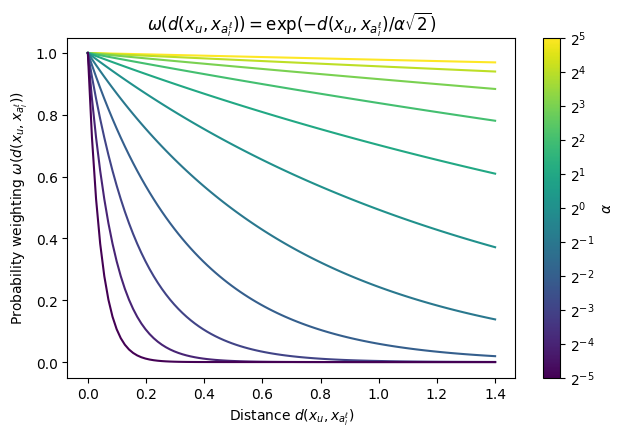

In [85]:
# Plot the connection probability function against α

alphas = [2**(-i) for i in range(-5, 6)] # Initialise values of α

deltas = np.linspace(0, math.sqrt(2),101)[:-1] # Initialise values of ẟ = d(xᵤ,xₐ)
omegas = [] # Initialise an array for values of ω

# For each α find the distribution of ω for all ẟ
for alpha in alphas:
    omegas.append([math.exp(-delta/(math.sqrt(2)*alpha)) for delta in deltas])

# Plot the resulting distributions
fig = plt.figure(figsize=(8,4))
ax = fig.add_axes([0.10,0.10,0.70,0.85])

cmap = plt.cm.viridis

norm = clr.SymLogNorm(
    linthresh=1e-3,
    vmin=min(alphas),
    vmax=max(alphas),
    base=2,
)

for alpha, probs in zip(alphas, omegas):
    plt.plot(deltas, probs, color=cmap(norm(alpha)))
    

sm = plt.cm.ScalarMappable(cmap = cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='$\\alpha$')

plt.xlabel('Distance $d(x_u, x_{a^\\ell_i})$')
plt.ylabel('Probability weighting $\\omega(d(x_u, x_{a^\\ell_i}))$')

plt.title('$\\omega(d(x_u, x_{a^\\ell_i})) = \\exp(-{d(x_u, x_{a^\\ell_i})} / {\\alpha \\sqrt{2}})$')
plt.show()


## Expected Weighting for Nodes

$\overline \omega (\mathbf x_u) 
= \int_0^1 \omega (d (\mathbf x_u, \mathbf x_{a^\ell_i})) 
\cdot f_{\mathbf X_{\mathcal A}}(\mathbf x_{a^\ell_i}) 
~ \text{d}\mathbf x_{a^\ell_i}$

Generate a lookup table for the expected weighting of a node at each position.

In [53]:
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)

When $\alpha$ is high, the connection function decays slowly and so on average values of $\omega$ are higher. Nodes near the centre have higher values of $\overline \omega$ because they are closer to all possible affiliation positions on average, compared to nodes near the corners. When $\alpha$ is low, average values of $\omega$ are lower and more evenly spread.

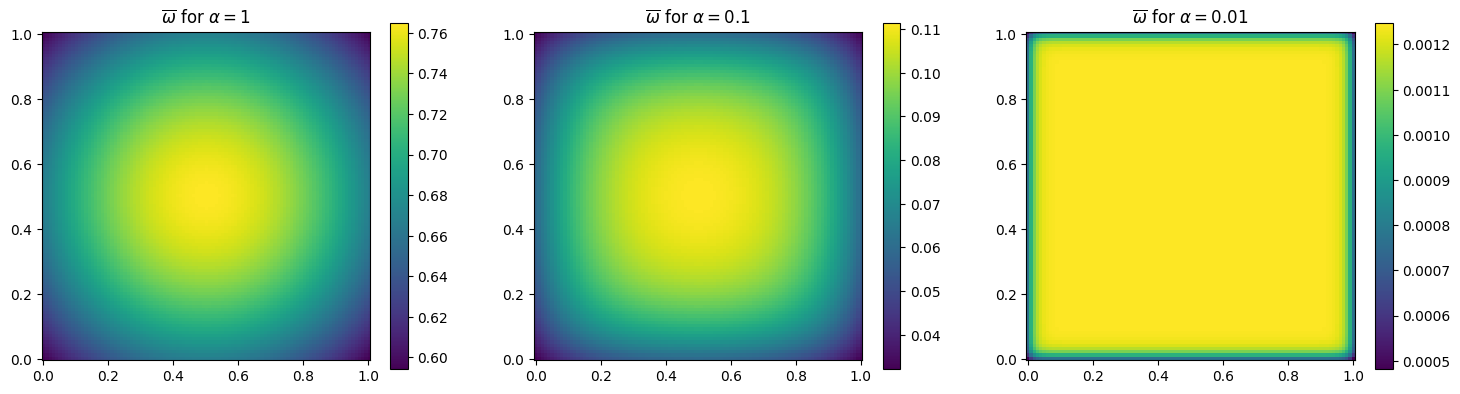

In [54]:
# Plot the expected weighting values
original_alpha = cfg.connection.alpha
fig, axs = plt.subplots(1, 3, figsize = (18, 6))

# High alpha
high_alpha = 1
cfg.connection.alpha = high_alpha
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
im = axs[0].imshow(weighting_lkup)
fig.colorbar(im, shrink=0.75)
axs[0].set_xticklabels([i/100 for i in axs[0].get_xticks()])
axs[0].set_yticklabels([i/100 for i in axs[0].get_yticks()])
axs[0].invert_yaxis()
axs[0].set_title("$\overline{\\omega}$ for $\\alpha=$" + str(high_alpha))

# Medium alpha
high_alpha = 0.1
cfg.connection.alpha = high_alpha
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
im = axs[1].imshow(weighting_lkup)
fig.colorbar(im, shrink=0.75)
axs[1].set_xticklabels([i/100 for i in axs[0].get_xticks()])
axs[1].set_yticklabels([i/100 for i in axs[0].get_yticks()])
axs[1].invert_yaxis()
axs[1].set_title("$\overline{\\omega}$ for $\\alpha=$" + str(high_alpha))

# Low alpha
low_alpha = 0.01
cfg.connection.alpha = low_alpha
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
im = axs[2].imshow(weighting_lkup)
fig.colorbar(im, shrink=0.75)
axs[2].set_xticklabels([i/100 for i in axs[1].get_xticks()])
axs[2].set_yticklabels([i/100 for i in axs[1].get_yticks()])
axs[2].invert_yaxis()
axs[2].set_title("$\overline{\\omega}$ for $\\alpha=$" + str(low_alpha))

cfg.connection.alpha = original_alpha # Reset alpha
plt.show()

## Pairwise Connection Probabilities

### Space-Independent Case

In the uniform case, two nodes $u$ and $v$ connect in layer $\ell$ with probability $1/(K^\ell)$, independent of their embeddings $\mathbf x_u$ and $\mathbf x_v$.

For example, for $K = 100$ we expect two nodes to connect with probability 0.01.

In [55]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0, 1), random.uniform(0,1))
v_pos = (random.uniform(0, 1), random.uniform(0,1))

alpha = 10
K = 100

n_trials = 10_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ 0.01.')

Two nodes at positions (0.528, 0.215) and (0.568, 0.937) connect with probability 0.0095 ≈ 0.01.


In [56]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0, 1), random.uniform(0,1))
v_pos = (random.uniform(0, 1), random.uniform(0,1))

alpha = 10
K = 100

n_trials = 10_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ 0.01.')

Two nodes at positions (0.373, 0.913) and (0.317, 0.044) connect with probability 0.0104 ≈ 0.01.


In [ ]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0, 1), random.uniform(0,1))
v_pos = (random.uniform(0, 1), random.uniform(0,1))

alpha = 10
K = 100

n_trials = 10_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ 0.01.')

Two nodes at positions (0.288, 0.007) and (0.911, 0.700) connect with probability 0.0089 ≈ 0.01.


In [57]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0, 1), random.uniform(0,1))
v_pos = (random.uniform(0, 1), random.uniform(0,1))

alpha = 10
K = 100

n_trials = 10_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ 0.01.')

Two nodes at positions (0.576, 0.413) and (0.137, 0.130) connect with probability 0.0097 ≈ 0.01.


### Hard Geometric Case

In the Voronoi case, two nodes connect in layer $\ell$ if they fall into the same Voronoi cell. This happens with probability,
<br>
$K^\ell \cdot \int_{\mathbf S}  \exp (- (K^\ell -1) \cdot |B_{d(u, a^\ell_i)}(\mathbf x_v) \cap (B_{d(v, a^\ell_i)}(\mathbf x_u))|) \text{d}\mathbf x_{a^\ell_i}$

In [65]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))
v_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))

# Empirical result

alpha = 0.001
K = 100

n_trials = 100_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
# Analytical result

original_n_trials = cfg.analysis.mc_n_trials
cfg.analysis.mc_n_trials = 10_000

p = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)

cfg.analysis.mc_n_trials = original_n_trials

 
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ {p:.3f}.')

Two nodes at positions (0.512, 0.493) and (0.497, 0.483) connect with probability 0.77086 ≈ 0.770.


In [219]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))
v_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))

# Empirical result

alpha = 0.001
K = 100

n_trials = 100_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
# Analytical result

original_n_trials = cfg.analysis.mc_n_trials
cfg.analysis.mc_n_trials = 10_000

p = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)

cfg.analysis.mc_n_trials = original_n_trials

 
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ {p:.3f}.')

Two nodes at positions (0.488, 0.494) and (0.516, 0.507) connect with probability 0.63127 ≈ 0.632.


In [220]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))
v_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))

# Empirical result

alpha = 0.001
K = 100

n_trials = 100_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
# Analytical result

original_n_trials = cfg.analysis.mc_n_trials
cfg.analysis.mc_n_trials = 10_000

p = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)

cfg.analysis.mc_n_trials = original_n_trials

 
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ {p:.3f}.')

Two nodes at positions (0.496, 0.487) and (0.502, 0.481) connect with probability 0.88213 ≈ 0.883.


In [221]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0.4, 0.6), random.uniform(0.4, 0.6))
v_pos = (random.uniform(0.4, 0.6), random.uniform(0.4, 0.6))

# Empirical result

alpha = 0.001
K = 100

n_trials = 100_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
# Analytical result

original_n_trials = cfg.analysis.mc_n_trials
cfg.analysis.mc_n_trials = 10_000

p = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)

cfg.analysis.mc_n_trials = original_n_trials

 
print(f'Two nodes at positions ({u_pos[0]:.3f}, {u_pos[1]:.3f}) and ({v_pos[0]:.3f}, {v_pos[1]:.3f}) connect with probability {successes / n_trials} ≈ {p:.3f}.')

Two nodes at positions (0.557, 0.545) and (0.457, 0.583) connect with probability 0.09047 ≈ 0.092.


#### Pairwise Connection Probability by Distance

In the hard geometric case, nodes which are further apart are less likely to connect. The probability that a pair of nodes a distance of $\delta$ apart connect is <br>
$\iint_{\mathbf S^2, d(\mathbf x_u, \mathbf x_v) = \delta} \mathbb P (u \sim_\ell v ~|~ \mathbf x_u, \mathbf x_v) ~\text{d}\mathbf x_u ~\text{d}\mathbf x_v $ <br>
where <br>
$\mathbb P (u \sim_\ell v ~|~ \mathbf x_u, \mathbf x_v)  = K^\ell \in_{\mathbf S} \exp (- (K^\ell - 1) \cdot |B_{d(u, a_i^\ell)}(\mathbf x_u) \cup B_{d(v, a_i^\ell)}(\mathbf x_v) | ) ~\text{d}\mathbf x_{a_i^\ell}$ <br>
and $B_{d(u, a_i^\ell)}(\mathbf x_u)$ is the ball centred on $\mathbf x_u$ passing through $\mathbf x_{a_i^\ell}$.

In [32]:
# Empirical Tests

# Initialise values for δ and K.
deltas = np.linspace(0, 1/math.sqrt(2), 50)
K = 100

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 0.001

successes = [0 for delta in deltas] # Initialise to count successes

for i, delta in enumerate(deltas):
    for _ in range(cfg.analysis.mc_n_trials):

        # Sample two uniform points a distance δ apart
        v_pos = (-1, -1)
        while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
            u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
            theta = np.random.uniform(0, 2*math.pi)
            v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])


        # Generate K affiliation positions.
        aff_pos = {a : (np.random.uniform(0,1), np.random.uniform(0,1)) for a in range(K)}

        # Find the closest affiliation to u. 
        u_dist = {a: d(u_pos, aff_pos[a], cfg) for a in aff_pos}
        u_aff = min(u_dist, key=u_dist.get)

        # Find the closest affiliation to v. 
        v_dist = {a: d(v_pos, aff_pos[a], cfg) for a in aff_pos}
        v_aff = min(v_dist, key=v_dist.get)

        # u and v successfully connect if they choose the same affiliation. 
        successes[i] += int(u_aff == v_aff)

cfg.connection.alpha = original_alpha
        
empirical_probs = [success / cfg.analysis.mc_n_trials for success in successes]

In [33]:
# Analytical Results
analytical_probs = [trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, delta, K) for delta in deltas]

KeyboardInterrupt: 

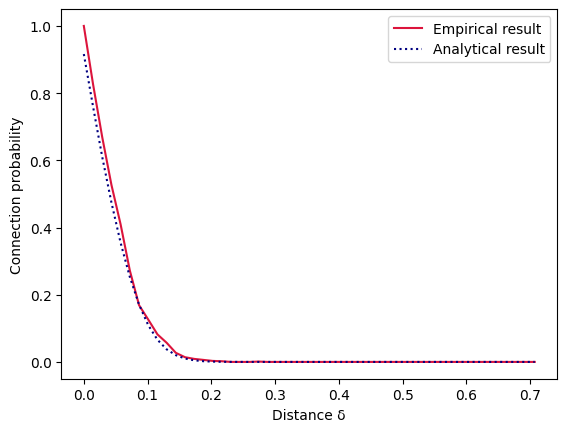

In [63]:
# Plot empirical against analytical results

plt.plot(deltas, empirical_probs, c='crimson', label='Empirical result')
plt.plot(deltas, analytical_probs, c='navy', ls=':', label='Analytical result')

plt.xlabel('Distance δ')
plt.ylabel('Connection probability')
plt.legend()

plt.show()

## Density

### Space-Independent Case

In the uniform case the expected density of a single layer $G^\ell$ is $\frac{1}{K^\ell}$.

In [78]:
# Empirical Tests

original_L = cfg.network.n_layers
original_Ks = cfg.network.n_affiliations
original_alpha = cfg.connection.alpha

cfg.network.n_layers = 1
cfg.network.n_affiliations = [100]
cfg.connection.alpha = 100

n_trials = 1_000

total = 0 

for _ in range(n_trials):
    G, _ = gen(cfg, rng)
    total += nx.density(G)

print(f'The density of a single layer with 100 affiliations is {total/n_trials} ≈ 0.01.')

cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_Ks
cfg.connection.alpha = original_alpha

The density of a single layer with 100 affiliations is 0.010002598598598594 ≈ 0.01.


The expected density of the monoplex representation of $G$ is $1 - \prod_{\ell=1}^L \left( 1- \frac{1}{K^\ell}\right)$.

In [9]:
print(f'The expected density of a network with affiliation sizes {cfg.network.n_affiliations} is {1 - math.prod([1 - (1/K) for K in cfg.network.n_affiliations])}.')

The expected density of a network with affiliation sizes [25, 50, 100, 200, 400] is 0.07558179759999994.


In [10]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

n_trials = 100

total = 0 

for _ in range(n_trials):
    G, _ = gen(cfg, rng)
    total += nx.density(G)

expected_rho = 1 - math.prod([1 - (1/K) for K in cfg.network.n_affiliations])

cfg.connection.alpha = original_alpha

print(f'The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is {total/n_trials} ≈ 0.076.')

The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is 0.07554604604604606 ≈ 0.076.


### CURRENT Hard Geometric Case

When node and affiliation embeddings are uniform, the density of a single layer $G^\ell$ is approximately $\frac{1.28 +\varepsilon}{K^\ell}$.

In [19]:
# Empirical Tests

original_L = cfg.network.n_layers
original_Ks = cfg.network.n_affiliations
original_alpha = cfg.connection.alpha

cfg.network.n_layers = 1
cfg.network.n_affiliations = [100]
cfg.connection.alpha = 0.001
cfg.metric_space.toroidal = True

n_trials = 100

total = 0 

for _ in range(n_trials):
    G, _ = gen(cfg, rng)
    total += nx.density(G)

print(f'The density of a single layer with 100 affiliations is {total/n_trials} ≈ 0.0128.')

cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_Ks
cfg.connection.alpha = original_alpha
cfg.metric_space.toroidal = False

The density of a single layer with 100 affiliations is 0.012638178178178172 ≈ 0.0128.


When $\mathbf S$ is the unit square, we expect boundary effects to increase the density slightly.

In [20]:
# Empirical Tests

original_L = cfg.network.n_layers
original_Ks = cfg.network.n_affiliations
original_alpha = cfg.connection.alpha

cfg.network.n_layers = 1
cfg.network.n_affiliations = [100]
cfg.connection.alpha = 0.001

n_trials = 100

total = 0 

for _ in range(n_trials):
    G, _ = gen(cfg, rng)
    total += nx.density(G)

print(f'The density of a single layer with 100 affiliations is {total/n_trials} ≈ 0.0128 + ε.')

cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_Ks
cfg.connection.alpha = original_alpha

The density of a single layer with 100 affiliations is 0.0130174974974975 ≈ 0.0128 + ε.


The expected density of the monoplex representation of $G$ is <br>
$
\iint_{\mathbf S^2} \left[ 1- \prod_{\ell=1}^L \left(1 - \mathbb P(u \sim_\ell v ~|~ \mathbf x_u, \mathbf x_v) \right) \right] \text{d}x_u \text{d}x_v,
$
<br>where
$K^\ell \cdot \int_{\mathbf S}  \exp (- (K^\ell -1) \cdot |B_{d(u, a^\ell_i)}(\mathbf x_v) \cap (B_{d(v, a^\ell_i)}(\mathbf x_u))|) \text{d}\mathbf x_{a^\ell_i}$


In [68]:
n = 100

est_rho = 0
for _ in range(n):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    prob = 1
    for K in cfg.network.n_affiliations:
        prob *= 1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K)
    est_rho += 1 - prob

print(f'The expected density of a network with affiliation sizes {cfg.network.n_affiliations} is {est_rho / n}.')

The expected density of a network with affiliation sizes [25, 50, 100, 200, 400] is 0.06943734891322777.


In [87]:
n = 20

est_rho = 0

for delta in np.linspace(0, 1.3, n):
    print(delta)
    prob = 1
    for K in cfg.network.n_affiliations:
        prob *= 1 - mc_voronoi_pairwise_delta_connection_prob(cfg, delta, K)

    est_rho += (1 - prob) * sq_line_picking_prob(cfg, delta)

#for _ in range(n):
#    u_pos = (random.uniform(0,1), random.uniform(0,1))
#    v_pos = (random.uniform(0,1), random.uniform(0,1))

  #  prob = 1
  #  for K in cfg.network.n_affiliations:
  #      prob *= 1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K)
  #  est_rho += 1 - prob

print(f'The expected density of a network with affiliation sizes {cfg.network.n_affiliations} is {est_rho / n}.')

0.0
0.06842105263157895
0.1368421052631579
0.20526315789473687
0.2736842105263158
0.34210526315789475
0.41052631578947374
0.4789473684210527
0.5473684210526316
0.6157894736842106
0.6842105263157895
0.7526315789473684
0.8210526315789475
0.8894736842105264
0.9578947368421054
1.0263157894736843
1.0947368421052632
1.1631578947368422
1.231578947368421
1.3
The expected density of a network with affiliation sizes [25, 50, 100, 200, 400] is 0.040888517198146145.


In [72]:
n = 10_000

est_rho = 0
for _ in range(n):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    prob = 1
    for K in cfg.network.n_affiliations:
        prob *= 1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K)
    est_rho += 1 - prob

print(f'The expected density of a network with affiliation sizes {cfg.network.n_affiliations} is {est_rho / n}.')

The expected density of a network with affiliation sizes [25, 50, 100, 200, 400] is 0.059046344972237964.


In [73]:
n = 10_000

est_rho = 0
for _ in range(n):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    prob = 1
    for K in cfg.network.n_affiliations:
        prob *= 1 - trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K)
    est_rho += 1 - prob

print(f'The expected density of a network with affiliation sizes {cfg.network.n_affiliations} is {est_rho / n}.')

The expected density of a network with affiliation sizes [25, 50, 100, 200, 400] is 0.056297230411492066.


In [22]:
# Empirical Tests

original_alpha = cfg.connection.alpha

cfg.connection.alpha = 0.001
cfg.metric_space.toroidal = True

n_trials = 10

total = 0 

for _ in range(n_trials):
    G, _ = gen(cfg, rng)
    total += nx.density(G)

print(f'The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is {total/n_trials} ≈ 0.0128.')

cfg.connection.alpha = original_alpha
cfg.metric_space.toroidal = False

The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is 0.06729369369369369 ≈ 0.0128.


In [76]:
# Empirical Tests

original_alpha = cfg.connection.alpha

cfg.connection.alpha = 0.001

n_trials = 100

total = 0 

for _ in range(n_trials):
    G, _ = gen(cfg, rng)
    total += nx.density(G)

print(f'The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is {total/n_trials} ≈ 0.0128.')

cfg.connection.alpha = original_alpha

The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is 0.0687648448448448 ≈ 0.0128.


In [168]:
deltas = np.linspace(0, 0.7, 2)
print(deltas)
conn = [mc_voronoi_pairwise_delta_connection_prob(cfg, delta, 100) for delta in deltas]
embe = [sq_line_picking_prob(cfg, delta) for delta in deltas]

print(conn, embe)

[0.  0.7]
[0.943317488592056, 4.182183229597818e-34] [np.float64(0.0), np.float64(1.1642297150257102)]


In [ ]:
def tricky_circle_calc(cfg, u_pos, v_pos, a_pos):
    

In [ ]:
def test_mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K):
    """
    Monte-Carlo approximation of the probability that two nodes at positions u_pos = (xᵤ, yᵤ) and v_pos = (xᵥ, yᵥ) connect in the Voronoi scheme.
    """
    total = 0 # Initialise total for numerical integration average.

    # Take cfg.analysis.mc_n_trials samples of position for a
    for _ in range(cfg.analysis.mc_n_trials):
        a_pos = (random.uniform(0,1), random.uniform(0,1))

        # The probability that u chooses a is the void probability of the circle centred on u with radius d(u, a).
        area_u = math.pi * d(u_pos, a_pos, cfg)**2
        void_prob_u = math.e ** (-(K-1)*area_u)

        # The probability that v chooses a given that u chooses a is the void probability of the union of the circle centred on v with radius d(v, a) with the complement of the circle above centred on u.
        area_v = catchment_area(cfg, u_pos, v_pos, a_pos) - math.pi * d(u_pos, a_pos, cfg)**2
        void_prob_v = math.e ** (-(K-1)*area_v)

        # P(a(u) = a ∩ a(v) = a) = P(a(v) = a | a(u) = a)·P(a(u) = a)
        total += void_prob_u * void_prob_v
            
    return K * total / cfg.analysis.mc_n_trials

In [127]:
# Empirical Tests

original_alpha = cfg.connection.alpha

cfg.connection.alpha = 0.001

n_trials = 1000

total = 0 

for _ in range(n_trials):
    G, _ = gen(cfg, rng)
    total += nx.density(G)

print(f'The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is {total/n_trials} ≈ 0.0128.')

cfg.connection.alpha = original_alpha

The density of a network with layers with 25, 50, 100, 200 and 400 affiliations is 0.06764043643643639 ≈ 0.0128.


In [130]:
n_trials = 30

total_1 = 0
total_2 = 0
i = 0

for x_u in np.linspace(0, 1, n_trials):
    for y_u in np.linspace(0, 1, n_trials):
        for x_v in np.linspace(0, 1, n_trials):
            for y_v in np.linspace(0, 1, n_trials):
                u_pos = (x_u, y_u)
                v_pos = (x_v, y_v)

                total_1 += 1 - math.prod([1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K) for K in cfg.network.n_affiliations])
                total_2 += 1 - math.prod([1 - trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K) for K in cfg.network.n_affiliations])

                if (i + 1) % 1000 == 0:
                    print(i, total_1 / (i+1), total_2 / (i+1))
                i += 1

999 0.025722698211450817 0.02855194772557715
1999 0.024939510522190688 0.026906543833238507
2999 0.024585471681333355 0.0263429843950024
3999 0.024657707066902977 0.026325819907199184
4999 0.02502749731155285 0.026496931891700888
5999 0.02536742724131844 0.02669874071121798
6999 0.025617131840501312 0.026880828799292208
7999 0.02579650774362149 0.027033041770682897


KeyboardInterrupt: 

In [134]:
cfg

{'seed': 42,
 'n_runs': 10,
 'network': {'n_nodes': 1000,
  'n_layers': 5,
  'n_affiliations': [25, 50, 100, 200, 400],
  'layer_labels': ['l1', 'l2', 'l3', 'l4', 'l5']},
 'metric_space': {'square_side': 1,
  'distance': 'euclidean',
  'toroidal': False},
 'embedding': {'nodes': 'uniform', 'affiliations': 'uniform'},
 'connection': {'function': 'exponential_decay', 'alpha': 0.001},
 'visualization': {'plot_network': True,
  'plot_degree_distribution': True,
  'show': False},
 'analysis': {'omega_lookup_res': 101,
  'mc_n_trials': 1000,
  'trapezoidal_res': 101},
 'output': {'plots': {'degree_dist': True,
   'degree_dist_layers': True,
   'embededness': True,
   'network_visualization': True,
   'save': True,
   'show': False}}}

In [162]:
u_pos = (0.4, 0.4)
v_pos = (0.4, 0.4)

a_pos = (0.5, 0.5)
K = 100
delta = 0.1

V = catchment_area(cfg, u_pos, v_pos, a_pos)

total = 0
n = 1000
for V in np.linspace(0, 1, n):
    total += (1 - V) ** (K - 1)

print(K * total / n)

total = 0

for _ in range(n):
    v_pos = (-1, -1)
    while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
        u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
        theta = np.random.uniform(0, 2*math.pi)
        v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])


    a_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
    V = catchment_area(cfg, u_pos, v_pos, a_pos)

    total += (1 - V) ** (K - 1)

print(K * total / n) 

1.049825694753936
-3.4314089407443577e+55


In [139]:
[trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0.5, K) for K in cfg.network.n_affiliations]

[4.0863495078693934e-05,
 2.15979955092912e-09,
 6.2984809868137424e-18,
 5.492967632982803e-35,
 4.2333003447979e-69]

In [140]:
[trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0.1, K) for K in cfg.network.n_affiliations]

[0.42156202646586216,
 0.26460884644467525,
 0.1129728201408546,
 0.022433192419091995,
 0.000942857068703207]

In [142]:
[trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0.05, K) for K in cfg.network.n_affiliations]

[0.6454709287479189,
 0.545357620401173,
 0.4168813698776831,
 0.2608905155453179,
 0.11157479554243072]

In [143]:
[trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0.01, K) for K in cfg.network.n_affiliations]

[0.8332548127019526,
 0.8281253485758724,
 0.804156631799797,
 0.7672837754699406,
 0.7092806526427495]

In [144]:
[trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0.005, K) for K in cfg.network.n_affiliations]

[0.859222381903034,
 0.8575549743117119,
 0.8584381048012485,
 0.8457319219769659,
 0.8179845917450442]

In [145]:
[trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0.001, K) for K in cfg.network.n_affiliations]

[0.8745632796493903,
 0.8913883661891453,
 0.9001860074473852,
 0.909136305102138,
 0.9091797548818915]

In [141]:
[trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0, K) for K in cfg.network.n_affiliations]

[0.8811601237410535,
 0.8970961702199253,
 0.9148165996969231,
 0.9228233561918846,
 0.9331829331860706]

In [131]:
deltas = np.linspace(0, 1.4, 2)
analytical_probs = [1 - math.prod([1 - trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, delta, K) for K in cfg.network.n_affiliations]) for delta in deltas]

KeyboardInterrupt: 

In [ ]:
analytical_probs

In [128]:
n_trials = 300_000

total_1 = 0
total_2 = 0

for i in range(n_trials):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    total_1 += 1 - math.prod([1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K) for K in cfg.network.n_affiliations])
    total_2 += 1 - math.prod([1 - trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K) for K in cfg.network.n_affiliations])

    if (i + 1) % 1000 == 0:
        print(i, total_1 / (i+1), total_2 / (i+1))

999 0.04799183948819331 0.04604009971934961
1999 0.048945748905212874 0.047023472015125
2999 0.05563255071642798 0.053720786380155955
3999 0.05592548162050523 0.05401209821330302
4999 0.056799991623637004 0.05474427637725581
5999 0.05479333901811213 0.05283423893267091
6999 0.05500688131876006 0.053076007573649
7999 0.053935426971892485 0.05204738986209036
8999 0.05430385213516893 0.05240821151316991
9999 0.054395077799331136 0.05256685826941428
10999 0.05602794149628989 0.05414331845829869
11999 0.05637882343916259 0.05449056163037224
12999 0.05635236180123338 0.05446919372356092
13999 0.0565190531629601 0.05460471208092634
14999 0.05665317504940494 0.05471309158848072
15999 0.056725082882777354 0.05474455147594652
16999 0.05672673738961054 0.0547298349360752
17999 0.0570201655676537 0.05503979551884806
18999 0.057272042395254956 0.05531336987538796
19999 0.056945456675079914 0.05498220024180733
20999 0.056937791719984296 0.05497365694368804
21999 0.05678957545795543 0.054834183166902

KeyboardInterrupt: 

In [97]:
n_trials = 100_000

total = 0

for _ in range(n_trials):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    total += 1 - math.prod([1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K) for K in cfg.network.n_affiliations])

total / n_trials

(0.6783124237430287, 0.5923837601684055) (0.15275292900003512, 0.09886922492430361) (0.33109153617493015, 0.9621504428164293) 1.0144747298185453 0.5072373649092725 1.0000000000000002
(0.15586585199568637, 0.5022704840801706) (0.9072425516912951, 0.11707677179301479) (0.9747879850063992, 0.24883399528386807) 0.2961239706862238 0.14806198534311174 1.000000000000001


0.05844129575988516

#### CURRENT Pairwise Connection Probability

In [282]:
cfg.metric_space.toroidal = True

In [303]:
# Initialise values for δ.
deltas = np.linspace(0, 1/math.sqrt(2), 50)

In [315]:
cfg.network.n_nodes = 10_000
cfg.network.n_affiliations = [650,4350,475,150,130]

In [317]:
# Empirical Tests
original_alpha = cfg.connection.alpha
cfg.connection.alpha = 0.001

successes = [0 for delta in deltas] # Initialise to count successes

for i, delta in enumerate(deltas):
    for _ in range(cfg.analysis.mc_n_trials):

        # Sample two uniform points a distance δ apart
        v_pos = (-1, -1)
        while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
            u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
            theta = np.random.uniform(0, 2*math.pi)
            v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])

        connect = False

        for K in cfg.network.n_affiliations:
            # Generate K affiliation positions.
            aff_pos = {a : (np.random.uniform(0,1), np.random.uniform(0,1)) for a in range(K)}

            # Find the closest affiliation to u. 
            u_dist = {a: d(u_pos, aff_pos[a], cfg) for a in aff_pos}
            u_aff = min(u_dist, key=u_dist.get)

            # Find the closest affiliation to v. 
            v_dist = {a: d(v_pos, aff_pos[a], cfg) for a in aff_pos}
            v_aff = min(v_dist, key=v_dist.get)

            if u_aff == v_aff:
                connect = True

        # u and v successfully connect if they choose the same affiliation. 
        successes[i] += int(connect)

cfg.connection.alpha = original_alpha
        
empirical_probs = [success / cfg.analysis.mc_n_trials for success in successes]

In [316]:
# Analytical Results
analytical_probs = [1 - math.prod([1 - trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, delta, K) for K in cfg.network.n_affiliations]) for delta in deltas]

In [319]:
sum([x * y for x, y in zip(normalised_dist_dist, analytical_probs)]) / len(analytical_probs)

np.float64(0.005424023938447463)

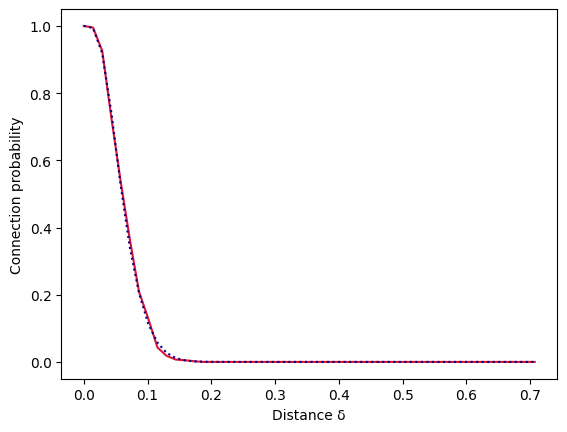

In [318]:
plt.plot(deltas, empirical_probs, c='crimson')
plt.plot(deltas, analytical_probs, c='navy', ls=':')

plt.xlabel('Distance δ')
plt.ylabel('Connection probability')

plt.show()

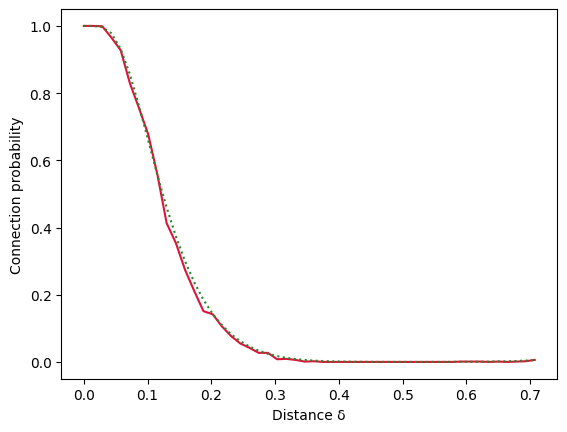

In [306]:
plt.plot(deltas, empirical_probs, c='crimson')
plt.plot(deltas, analytical_probs, c='navy', ls=':')

plt.xlabel('Distance δ')
plt.ylabel('Connection probability')

plt.show()

In [307]:
sum(tr_analytical_probs) / len(tr_analytical_probs)

0.19735572457729894

In [311]:
sum([x * y for x, y in zip(normalised_dist_dist, tr_analytical_probs)]) / len(tr_analytical_probs)

np.float64(0.013904170777524314)

In [314]:
rho = 0 
n = 20

for _ in range(n):
    G, _ = gen(cfg, rng)
    rho += nx.density(G)

rho/n

0.06496596596596596

alternative derivation

In [344]:
# Empirical Tests
total = 0

cfg.analysis.mc_n_trials = 10_000

for _ in range(cfg.analysis.mc_n_trials):

    # Sample two uniform points a distance δ apart
    u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
    v_pos = (np.random.uniform(0,1), np.random.uniform(0,1))

    connection_prob = 1 - math.prod([1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K) for K in cfg.network.n_affiliations])

    total += connection_prob

total / cfg.analysis.mc_n_trials

(0.6048172650582204, 0.011637910577258048) (0.6353660798041062, 0.37670049772728376) (0.35704845126019247, 0.032371463989940286) 0.4972696062620293 0.24863480313101463 1.0000000000000002
(0.418804490134016, 0.8739268907476795) (0.3478609736895648, 0.4111343053436549) (0.426550271128895, 0.8727395051067861) 0.015672524733539032 0.007836262366768253 1.0000000000001612
(0.6883450041537358, 0.005408684164307176) (0.41060731540590656, 0.7310803115799264) (0.9367278271666285, 0.3754608918052763) 0.8913644891912824 0.44568224459564115 1.0000000000000002
(0.40439144978962815, 0.44250757254759465) (0.7454421118316362, 0.0030838358018077106) (0.8414198558959277, 0.8366309542877433) 0.38428265180726456 0.19214132590363225 1.0000000000000002


0.015405120824088552

Why is it so low :(((((


##### OLD

In [327]:
n_trials = 10_000_000
dists = []

for _ in range(n_trials):
    u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
    v_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
    dists.append(d(u_pos, v_pos, cfg))

vals, bins, _ = plt.hist(dists, bins=1000)
plt.clf()
normalised_dist_dist = normalise_as_pdf(vals, bins[1] - bins[0])
mps = [(bins[i] + bins[i+1])/2 for i in range(len(bins) - 1)]

print('done')
#normalised_dist_dist = normalised_dist_dist[:300]
#mps = mps[:300]

#connection_probs = []

#for delta in mps:
#    connection_probs.append(mc_voronoi_pairwise_delta_connection_prob(cfg, delta, 100))

done


<Figure size 640x480 with 0 Axes>

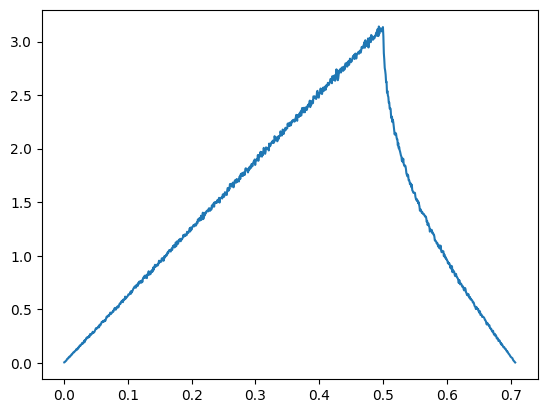

In [328]:
plt.plot(mps, normalised_dist_dist)
#plt.plot(mps, connection_probs)

In [334]:
vals, bins, _ = plt.hist(dists, bins=50)
plt.clf()
normalised_dist_dist = normalise_as_pdf(vals, bins[1] - bins[0])
mps = [(bins[i] + bins[i+1])/2 for i in range(len(bins) - 1)]

<Figure size 640x480 with 0 Axes>

In [335]:
bins

array([3.34694982e-04, 1.44656903e-02, 2.85966855e-02, 4.27276808e-02,
       5.68586761e-02, 7.09896714e-02, 8.51206667e-02, 9.92516619e-02,
       1.13382657e-01, 1.27513653e-01, 1.41644648e-01, 1.55775643e-01,
       1.69906638e-01, 1.84037634e-01, 1.98168629e-01, 2.12299624e-01,
       2.26430619e-01, 2.40561615e-01, 2.54692610e-01, 2.68823605e-01,
       2.82954601e-01, 2.97085596e-01, 3.11216591e-01, 3.25347586e-01,
       3.39478582e-01, 3.53609577e-01, 3.67740572e-01, 3.81871568e-01,
       3.96002563e-01, 4.10133558e-01, 4.24264553e-01, 4.38395549e-01,
       4.52526544e-01, 4.66657539e-01, 4.80788535e-01, 4.94919530e-01,
       5.09050525e-01, 5.23181520e-01, 5.37312516e-01, 5.51443511e-01,
       5.65574506e-01, 5.79705501e-01, 5.93836497e-01, 6.07967492e-01,
       6.22098487e-01, 6.36229483e-01, 6.50360478e-01, 6.64491473e-01,
       6.78622468e-01, 6.92753464e-01, 7.06884459e-01])

In [336]:
deltas

array([0.        , 0.01443075, 0.0288615 , 0.04329225, 0.057723  ,
       0.07215375, 0.0865845 , 0.10101525, 0.11544601, 0.12987676,
       0.14430751, 0.15873826, 0.17316901, 0.18759976, 0.20203051,
       0.21646126, 0.23089201, 0.24532276, 0.25975351, 0.27418426,
       0.28861501, 0.30304576, 0.31747651, 0.33190726, 0.34633802,
       0.36076877, 0.37519952, 0.38963027, 0.40406102, 0.41849177,
       0.43292252, 0.44735327, 0.46178402, 0.47621477, 0.49064552,
       0.50507627, 0.51950702, 0.53393777, 0.54836852, 0.56279927,
       0.57723003, 0.59166078, 0.60609153, 0.62052228, 0.63495303,
       0.64938378, 0.66381453, 0.67824528, 0.69267603, 0.70710678])

In [339]:
[x * y for x, y in zip(normalised_dist_dist, analytical_probs)]

[np.float64(0.04758360023248873),
 np.float64(0.13532167738530448),
 np.float64(0.2070333958866977),
 np.float64(0.23052350352117243),
 np.float64(0.21125870358858867),
 np.float64(0.16718482941569038),
 np.float64(0.1183887819674049),
 np.float64(0.07615006591871047),
 np.float64(0.04376773538542483),
 np.float64(0.02252315381883037),
 np.float64(0.010671404182745791),
 np.float64(0.004573995385415458),
 np.float64(0.0017917087038706887),
 np.float64(0.0006399311918437097),
 np.float64(0.0002106787331261449),
 np.float64(6.343660174602349e-05),
 np.float64(1.7577705569818853e-05),
 np.float64(4.465936286179731e-06),
 np.float64(1.0518980521710074e-06),
 np.float64(2.259561640415079e-07),
 np.float64(4.475881932793449e-08),
 np.float64(8.205650525683133e-09),
 np.float64(1.3762699068276824e-09),
 np.float64(2.1247173642336537e-10),
 np.float64(3.0325411436431355e-11),
 np.float64(3.9396059272819176e-12),
 np.float64(4.727014355597248e-13),
 np.float64(5.240067694270157e-14),
 np.float6

In [337]:
sum([x * y for x, y in zip(normalised_dist_dist, analytical_probs)]) / len(analytical_probs)

np.float64(0.025554199563805686)

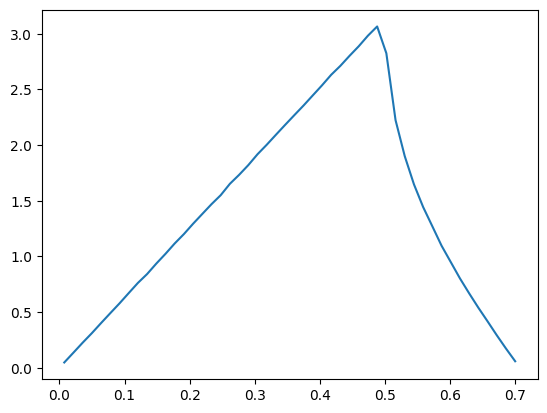

In [338]:
plt.plot(mps, normalised_dist_dist)

In [329]:
deltas

array([0.        , 0.01443075, 0.0288615 , 0.04329225, 0.057723  ,
       0.07215375, 0.0865845 , 0.10101525, 0.11544601, 0.12987676,
       0.14430751, 0.15873826, 0.17316901, 0.18759976, 0.20203051,
       0.21646126, 0.23089201, 0.24532276, 0.25975351, 0.27418426,
       0.28861501, 0.30304576, 0.31747651, 0.33190726, 0.34633802,
       0.36076877, 0.37519952, 0.38963027, 0.40406102, 0.41849177,
       0.43292252, 0.44735327, 0.46178402, 0.47621477, 0.49064552,
       0.50507627, 0.51950702, 0.53393777, 0.54836852, 0.56279927,
       0.57723003, 0.59166078, 0.60609153, 0.62052228, 0.63495303,
       0.64938378, 0.66381453, 0.67824528, 0.69267603, 0.70710678])

In [259]:
test_vals = [x * y for x, y in zip(normalised_dist_dist, connection_probs)]
sum(test_vals) / len(test_vals)

np.float64(0.030720281867358323)

Two nodes connect

In [ ]:
# Empirical tests



CURRENT: Monoplex Density

In [140]:
cfg.analysis.mc_n_trials = 1000 # 1000

In [144]:
cfg.metric_space.toroidal = True

In [ ]:
normalise_as_pdf()

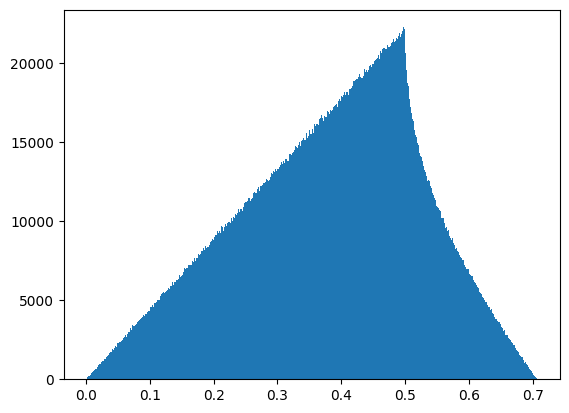

In [166]:
n_trials = 10000000

dists = []

for _ in range(n_trials):
    u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
    v_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
    dists.append(d(u_pos, v_pos, cfg))

plt.hist(dists, bins=1000)
plt.show()

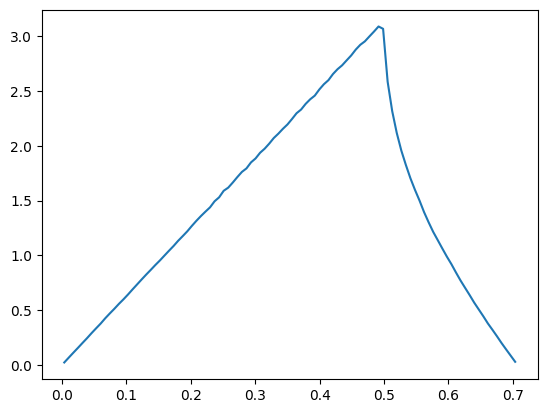

In [181]:
vals, bins, _ = plt.hist(dists, bins=100)
plt.clf()
normalised_vals = normalise_as_pdf(vals, bins[1] - bins[0])
mps = [(bins[i] + bins[i+1])/2 for i in range(len(bins) - 1)]
plt.plot(mps, normalised_vals)
plt.show()

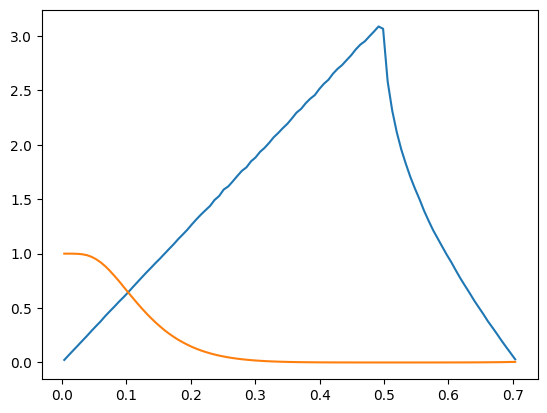

In [243]:
vals, bins, _ = plt.hist(dists, bins=100)
plt.clf()
normalised_vals = normalise_as_pdf(vals, bins[1] - bins[0])
mps = [(bins[i] + bins[i+1])/2 for i in range(len(bins) - 1)]
plt.plot(mps, normalised_vals)
plt.plot(mps, ps)
plt.show()

In [ ]:
test_vals = [x * y for x, y in zip(normalised_vals, ps)]
sum(test_vals) / len(test_vals)

In [247]:
sum(test_vals) / len(test_vals)

np.float64(0.09881768030421448)

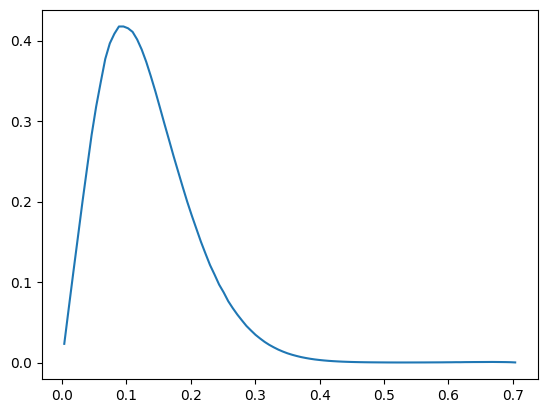

In [246]:
plt.plot(mps, test_vals)

In [248]:
cfg.analysis.mc_n_trials

1000

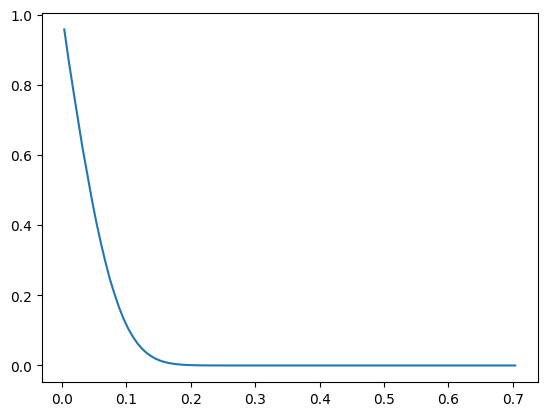

In [194]:
ps = []

for delta in mps:
    ps.append(mc_voronoi_pairwise_delta_connection_prob(cfg, delta, 100))

plt.plot(mps, ps)

In [201]:
sum([p*f for p, f in zip(ps, normalised_vals)])/ len(ps)

np.float64(0.017994618506126457)

(0.41369267717694314, 0.16532325569639506) (np.float64(0.8523283814339558), np.float64(0.31408306791591467)) (np.float64(0.7666666666666666), np.float64(0.5666666666666667)) 0.5334281722397246 0.26671408611986225 1.0000000000000002
(0.9555199796106275, 0.7845567336378672) (np.float64(0.63326970558269), np.float64(0.37681145351675355)) (np.float64(0.5333333333333333), np.float64(0.16666666666666666)) 0.465394928801896 0.23269746440094796 1.0000000000000002


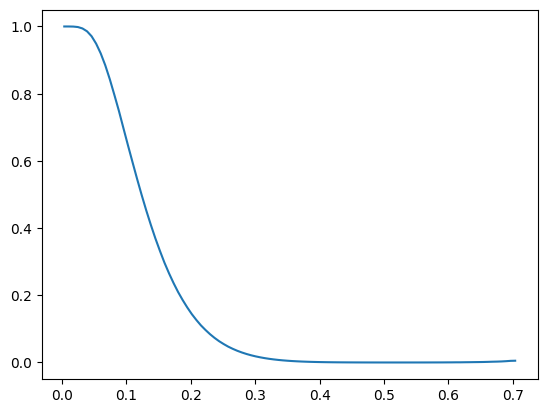

In [202]:
ps = []

for delta in mps:
    ps.append(1 - math.prod([1 - trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, delta, K) for K in cfg.network.n_affiliations]))

plt.plot(mps, ps)

In [210]:
sum([p*f for p, f in zip(ps, normalised_vals)])/ len(ps)

np.float64(0.09881768030421448)

In [213]:
cfg.connection.alpha = 0.001 # 0.01

In [217]:
rho = 0 
n = 10

for _ in range(n):
    G, _ = gen(cfg, rng)
    rho += nx.density(G)

rho/n

0.0691035035035035

In [216]:
cfg.metric_space.toroidal = False

In [205]:
nx.density(G)

0.07151151151151151

In [182]:
delta = 0.9

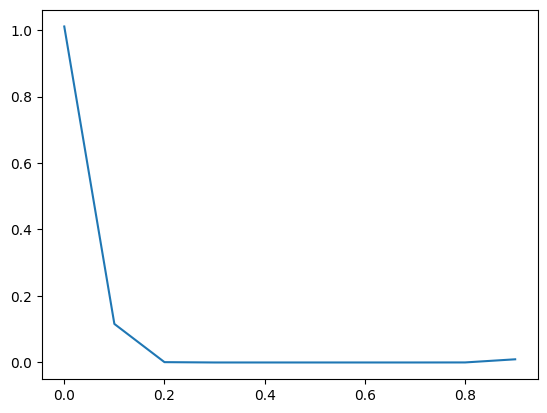

In [192]:
ps = []
deltas = list(np.linspace(0, 0.9, 10))

for delta in deltas:
    ps.append(trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, delta, 100))

plt.plot(deltas, ps)

In [183]:
1 - math.prod([1 - trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, delta, K) for K in cfg.network.n_affiliations])

0.13645796366931073

In [184]:
# Empirical tests

# Initialise values for δ and K.
original_alpha = cfg.connection.alpha
cfg.connection.alpha = 0.001

successes = 0 # Initialise to count successes

for j in range(cfg.analysis.mc_n_trials):

    connect = False

    # Sample two uniform points a distance δ apart
    v_pos = (-1, -1)
    while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
        u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
        theta = np.random.uniform(0, 2*math.pi)
        v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])

    for K in cfg.network.n_affiliations:
        # Generate K affiliation positions.
        aff_pos = {a : (np.random.uniform(0,1), np.random.uniform(0,1)) for a in range(K)}

        # Find the closest affiliation to u. 
        u_dist = {a: d(u_pos, aff_pos[a], cfg) for a in aff_pos}
        u_aff = min(u_dist, key=u_dist.get)

        # Find the closest affiliation to v. 
        v_dist = {a: d(v_pos, aff_pos[a], cfg) for a in aff_pos}
        v_aff = min(v_dist, key=v_dist.get)

        if u_aff == v_aff:
            connect = True

    # u and v successfully connect if they choose the same affiliation. 
    successes += int(connect)

cfg.connection.alpha = original_alpha
        
successes / cfg.analysis.mc_n_trials

0.096

In [126]:
# Empirical tests

# Initialise values for δ and K.
delta = 0.1
original_alpha = cfg.connection.alpha
cfg.connection.alpha = 0.001

K = 100

successes = 0 # Initialise to count successes


for j in range(cfg.analysis.mc_n_trials):
    # Sample two uniform points a distance δ apart
    v_pos = (-1, -1)
    while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
        u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
        theta = np.random.uniform(0, 2*math.pi)
        v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])

    # Generate K affiliation positions.
    aff_pos = {a : (np.random.uniform(0,1), np.random.uniform(0,1)) for a in range(K)}

    # Find the closest affiliation to u. 
    u_dist = {a: d(u_pos, aff_pos[a], cfg) for a in aff_pos}
    u_aff = min(u_dist, key=u_dist.get)

    # Find the closest affiliation to v. 
    v_dist = {a: d(v_pos, aff_pos[a], cfg) for a in aff_pos}
    v_aff = min(v_dist, key=v_dist.get)

    # u and v successfully connect if they choose the same affiliation. 
    successes += int(u_aff == v_aff)

cfg.connection.alpha = original_alpha
        
successes / cfg.analysis.mc_n_trials

0.11562

In [118]:
trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, 0.1, 100)

0.11753149698909894

In [119]:
mc_voronoi_pairwise_delta_connection_prob(cfg, 0.1, 100)

0.11954801798401975

Experiments with density

In [31]:
n = 200_000
K = 100

total = 0

for _ in range(n):
    pos_u = (random.uniform(0,1), random.uniform(0,1))
    pos_v = (random.uniform(0,1), random.uniform(0,1))

    total += trapezoidal_voronoi_pairwise_connection_prob(cfg, pos_u, pos_v, K)

total / n

(0.6342399682042404, 0.25259702345221435) (0.4669279523303286, 0.8394953583516833) (np.float64(0.5666666666666667), np.float64(0.23333333333333334)) 0.14053100494459164 0.07026550247229538 1.0000000000000062


ValueError: math domain error

In [10]:
quadrt_n = 25
K = 100

total = 0 
for x_u in np.linspace(0, 1, quadrt_n):
    for y_u in np.linspace(0, 1, quadrt_n):
        for x_v in np.linspace(0, 1, quadrt_n):
            for y_v in np.linspace(0, 1, quadrt_n):
                total += trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), K)

total / (quadrt_n ** 4)

0.010278634698551212

In [9]:
quadrt_n = 20
K = 100

total = 0 
for x_u in np.linspace(0, 1, quadrt_n):
    for y_u in np.linspace(0, 1, quadrt_n):
        for x_v in np.linspace(0, 1, quadrt_n):
            for y_v in np.linspace(0, 1, quadrt_n):
                total += trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), K)

total / (quadrt_n ** 4)

0.01019632980340346

## Triangle Counts - Needs Finishing

* We define *one-dimensional triangles* as those where all three edges exist in any one layer of the network. <br>
* A *three-dimensional triangle* is one where each edge of the triangle comes from a different layer, and a one-dimensional triangle on the same triplet of nodes does not exist.<br>
* *Two-dimensional triangles* are those where edges come from two layers of the network, and an equivalent one-dimensional triangle does not exist. In our framework a two-dimensional triangle cannot exist because there is complete closure within a layer.

### Space-Independent Case

First we find the average number of one-, two- and three-dimensional triangles in a space-independent network.

In [90]:
def _triangle_layer_dimension(edge_layers):
    e1, e2, e3 = edge_layers

    if e1 & e2 & e3:
        return 1

    all_layers = e1 | e2 | e3

    for a in all_layers:
        for b in all_layers:
            pair = {a, b}

            if (
                e1 & pair
                and e2 & pair
                and e3 & pair
            ):
                return 2

    return 3

In [88]:
def get_triangle_dimension_counts(G, layers):
    """
    Returns [n_1d, n_2d, n_3d] triangle counts.

    1d: triangle can be realized in one layer
    2d: triangle needs exactly two layers
    3d: triangle needs exactly three layers
    """
    edge_to_layers = {}

    for layer_idx, layer in enumerate(layers):
        for u, v in layer.edges():
            edge = frozenset((u, v))
            edge_to_layers.setdefault(edge, set()).add(layer_idx)

    counts = np.zeros(3, dtype=float)

    node_order = {node: i for i, node in enumerate(G.nodes())}
    neighbors = {node: set(G.neighbors(node)) for node in G.nodes()}

    for u in G.nodes():
        for v in neighbors[u]:
            if node_order[v] <= node_order[u]:
                continue

            common = neighbors[u] & neighbors[v]

            for w in common:
                if node_order[w] <= node_order[v]:
                    continue

                edge_layers = [
                    edge_to_layers[frozenset((u, v))],
                    edge_to_layers[frozenset((u, w))],
                    edge_to_layers[frozenset((v, w))],
                ]

                dim = _triangle_layer_dimension(edge_layers)

                counts[dim - 1] += 1

    return counts

In [93]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

avg_triangle_dimension_counts = [0, 0, 0]
for _ in range(cfg.analysis.mc_n_trials):
    G, layers = gen(cfg, rng)
    dim_counts = get_triangle_dimension_counts(G, layers)
    avg_triangle_dimension_counts = [sum([total_count, new_count]) for total_count, new_count in zip(avg_triangle_dimension_counts, dim_counts)]

avg_triangle_dimension_counts = [int(total / cfg.analysis.mc_n_trials) for total in avg_triangle_dimension_counts]
cfg.connection.alpha = original_alpha

print(f'The average number of one-dimensional triangles is {avg_triangle_dimension_counts[0]}.')
print(f'The average number of two-dimensional triangles is {avg_triangle_dimension_counts[1]}.')
print(f'The average number of three-dimensional triangles is {avg_triangle_dimension_counts[2]}.')

The average number of one-dimensional triangles is 353921.
The average number of two-dimensional triangles is 0.
The average number of three-dimensional triangles is 17720.


#### One-Dimensional Triangles

The expected number of one-dimensional triangles is given by $\overline \tau_{\text{1D}} = {N \choose 3} \cdot \left [ 1 - \prod_{\ell=1}^L \left(1 - \frac{1}{(K^\ell)^2} \right)\right]$

In [94]:
def expected_space_independent_1D_triangles(N, Ks):
    return math.comb(N, 3) * (1 - math.prod([1 - (1/(K**2)) for K in Ks]))

In [95]:
print(f'The expected number of one-dimensional triangles is {expected_space_independent_1D_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of one-dimensional triangles is 353992.92284777603.


For the parameters used in the paper, this is:

In [96]:
print(f'The expected number of one-dimensional triangles is {expected_space_independent_1D_triangles(10_000, [656,4700,326,7962,5817])}.')

The expected number of one-dimensional triangles is 1970042.468409362.


#### Three-Dimensional Triangles

The expected number of three-dimensional triangles is given by <br>
$\overline \tau_{\text{3D}} = {N\choose 3} \left[ \prod_{\ell = 1}^L \left(1 - \frac{1}{(K^\ell)^2} \right)
    -
    3\prod_{\ell=1}^L \left(1 - \frac{1}{{K^\ell}}\right) 
    +
    3 \prod_{\ell=1}^L \left(\frac{K^\ell - 1}{K^\ell}\right)^2 
    -
    \prod_{\ell=1}^L \frac{(K^\ell -1)(K^\ell - 2)}{(K^\ell)^2} \right]
$
 <br>This count only includes three-dimensional triangles which do not have one-dimensional equivalents.

In [97]:
def expected_space_independent_3D_triangles(N, Ks):
    return math.comb(N, 3) * (math.prod([1 - (1/(K**2)) for K in Ks]) 
    - 3 * math.prod([1 - (1/K) for K in Ks])
    + 3 * math.prod([(1 - (2/K) + (1/K**2)) for K in Ks])
    - math.prod([(1 - (3/K) + (2/K**2)) for K in Ks]))

In [98]:
print(f'The expected number of three-dimensional triangles is {expected_space_independent_3D_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of three-dimensional triangles is 17714.512254549893.


For the parameters used in the paper, this is:

In [99]:
print(f'The expected number of three-dimensional triangles is {expected_space_independent_3D_triangles(10_000, [656,4700,326,7962,5817])}.')

The expected number of three-dimensional triangles is 2764.6290205848745.


#### Total Triangles

The expected number of total triangles is given by <br> 
$\overline \tau = {N\choose 3} \left[ 1
    -
    3\prod_{\ell=1}^L \left(1 - \frac{1}{{K^\ell}}\right) 
    +
    3 \prod_{\ell=1}^L \left(\frac{K^\ell - 1}{K^\ell}\right)^2 
    -
    \prod_{\ell=1}^L \frac{(K^\ell -1)(K^\ell - 2)}{(K^\ell)^2} \right]
$

In [35]:
def expected_triangles(N, Ks):
    return math.comb(N, 3) * (1 
    - 3 * math.prod([1 - (1/K) for K in Ks])
    + 3 * math.prod([(1 - (2/K) + (1/K**2)) for K in Ks])
    - math.prod([(1 - (3/K) + (2/K**2)) for K in Ks]))

In [14]:
print(f'The expected number of triangles is {expected_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of triangles is 371707.4351023444.


For the parameters used in the paper, this is:

In [15]:
print(f'The expected number of triangles is {expected_triangles(10_000, [650,4350,475,150,130])}.')

The expected number of triangles is 18657977.4226702.


### Hard Geometric Case

First we find the average number of one-, two- and three-dimensional triangles in a hard geometric network.

In [100]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 0.01

avg_triangle_dimension_counts = [0, 0, 0]
for _ in range(cfg.analysis.mc_n_trials):
    G, layers = gen(cfg, rng)
    dim_counts = get_triangle_dimension_counts(G, layers)
    avg_triangle_dimension_counts = [sum([total_count, new_count]) for total_count, new_count in zip(avg_triangle_dimension_counts, dim_counts)]

avg_triangle_dimension_counts = [int(total / cfg.analysis.mc_n_trials) for total in avg_triangle_dimension_counts]
cfg.connection.alpha = original_alpha

print(f'The average number of one-dimensional triangles is {avg_triangle_dimension_counts[0]}.')
print(f'The average number of two-dimensional triangles is {avg_triangle_dimension_counts[1]}.')
print(f'The average number of three-dimensional triangles is {avg_triangle_dimension_counts[2]}.')

The average number of one-dimensional triangles is 663337.
The average number of two-dimensional triangles is 0.
The average number of three-dimensional triangles is 13354.


#### One-Dimensional Triangles

The number of one-dimensional triangles is given by

## Clustering Coefficients

### Uniform Case

Wedge Counts

In [ ]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

avg_wedge_dimension_counts = [0, 0]
for _ in range(cfg.analysis.mc_n_trials):
    G, layers = gen(cfg, rng)
    dim_counts = get_triangle_dimension_counts(G, layers)

    no_1D_wedges = 3 * dim_counts[0]
    total_wedges = sum([math.comb(d, 2) for v, d in G.degree])

    avg_wedge_dimension_counts[0] += no_1D_wedges
    avg_wedge_dimension_counts[1] += total_wedges - no_1D_wedges

avg_wedge_dimension_counts = [int(total / cfg.analysis.mc_n_trials) for total in avg_wedge_dimension_counts]
cfg.connection.alpha = original_alpha

print(f'The average number of one-dimensional wedges is {avg_wedge_dimension_counts[0]}.')
print(f'The average number of two-dimensional wedges is {avg_wedge_dimension_counts[1]}.')

[np.float64(10600608.0), np.float64(17792932.0)]
The average number of one-dimensional wedges is 1060060.
The average number of two-dimensional wedges is 1779293.


Global Clustering

In [41]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

avg_transitivity = 0
for _ in range(cfg.analysis.mc_n_trials):
    G, layers = gen(cfg, rng)
    avg_transitivity += nx.transitivity(G)

avg_transitivity /= cfg.analysis.mc_n_trials
cfg.connection.alpha = original_alpha

print(f'The average global clustering coefficient is {avg_transitivity}.')

The average global clustering coefficient is 0.3922979864776049.


#### One-Dimensional Wedges

Every triplet of nodes $u, v, w$ in the same affiliation in layer $\ell$ creates 3 wedges in layer $\ell$. Therefore, the number of one-dimensional wedges in $G$ is the number of one-dimensional triangles times 3. 

In [329]:
print(f'The expected number of one-dimensional wedges is {3 * expected_1D_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of one-dimensional wedges is 1061978.7685433282.


For the parameters used in the paper, this is:

In [330]:
print(f'The expected number of one-dimensional wedges is {3 * expected_1D_triangles(10_000, [650,4350,475,150,130])}.')

The expected number of one-dimensional wedges is 55215699.14741053.


#### Two-Dimensional Wedges

The expected number of two-dimensional wedges which do not have one-dimensional wedges is given by, <br>
$3 \cdot {N \choose 3} \left[
    \prod_{\ell = 1}^L \left(1 - \frac{1}{(K^\ell)^2} \right) 
    -
    2 \prod_{\ell = 1}^L \left(1 - \frac{1}{K^\ell} \right) 
    +
    \prod_{\ell = 1}^L \left (\frac{(K^\ell - 1)^2}{(K^\ell)^2} \right ) \right]$

In [341]:
def expected_2D_wedges(N, Ks):
    return 3 * math.comb(N, 3) * (math.prod([1 - (1/(K**2)) for K in Ks]) 
    - 2 * math.prod([1 - (1/K) for K in Ks])
    + math.prod([(1 - (1/K))**2 for K in Ks]))

In [ ]:
print(f'The expected number of two-dimensional wedges is {expected_2D_wedges(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of one-dimensional wedges is 1785762.0960957322.


For the parameters used in the paper, this is:

In [344]:
print(f'The expected number of two-dimensional wedges is {expected_2D_wedges(10_000, [650,4350,475,150,130])}.')

The expected number of two-dimensional wedges is 108935988.65229969.


#### Total Wedges

The total expected number of wedges is given by, <br>
$ 3 \cdot{N \choose 3} \cdot \left [ 1  
    -
    2 \prod_{\ell = 1}^L \left(1 - \frac{1}{K^\ell} \right) 
    +
    \prod_{\ell = 1}^L \left (\frac{(K^\ell - 1)^2}{(K^\ell)^2} \right ) \right]$

In [43]:
def expected_wedges(N, Ks):
    return 3 * math.comb(N, 3) * (1
    - 2 * math.prod([1 - (1/K) for K in Ks])
    + math.prod([(1 - (1/K))**2 for K in Ks]))

In [44]:
print(f'The expected number of wedges is {expected_wedges(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of wedges is 2847740.86463906.


For the parameters used in the paper, this is:

In [45]:
print(f'The expected number of wedges is {expected_wedges(10_000, [650,4350,475,150,130])}.')

The expected number of wedges is 164151687.7997102.


# TO SORT OUT

In [4]:
def p_delta_voronoi(cfg, delta, K):
    """
    Monte-Carlo approximation of the probability of two nodes distance δ apart connecting.
    """
    total = 0
    for _ in range(cfg.analysis.mc_n_trials):
        # Sample uniformly from the set of points δ apart inside the unit square.
        x_v = -1
        y_v = -1 
        while not 0 <= x_v <= 1 or not 0 <= y_v <= 1:
            x_u, y_u = (random.uniform(0,1), random.uniform(0,1))
            theta = random.uniform(0,2 * math.pi) # Choose θ uniformly 
            x_v, y_v = (x_u + delta * math.cos(theta), y_u + delta * math.sin(theta)) # Find the point v which is δ away from u and 

        p = trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), K)
        total += p

    return total / cfg.analysis.mc_n_trials

In [5]:
def voronoi_density():
    total = 0
    deltas  = np.linspace(0, math.sqrt(2), 11)[:-1]
    for delta in deltas:
        prob_not_connected = 1
        for K in cfg.network.n_affiliations:
            p_delta = p_delta_voronoi(cfg, delta, K)
            prob_not_connected *= (1-p_delta)
        total += prob_not_connected * sq_line_picking_prob(cfg, delta)
    return total / len(deltas)

In [6]:
voronoi_density()

np.float64(0.6689924018666702)

In [12]:
deltas = np.linspace(0, math.sqrt(2), 101)[:-1]
probs  = [p_delta_voronoi(cfg, delta, 100) for delta in deltas]

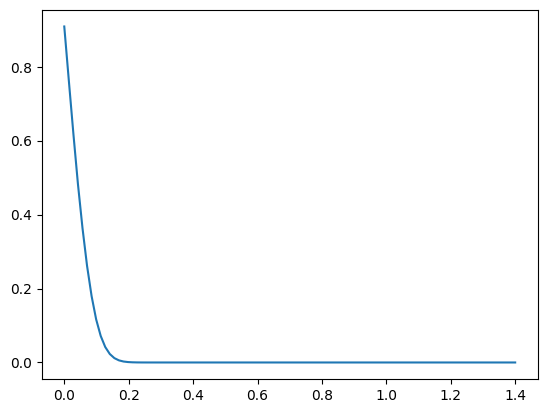

In [14]:
plt.plot(deltas, probs)

In [16]:
total = 0
for delta, prob in zip(deltas, probs):
    total += prob * sq_line_picking_prob(cfg, delta)
total /(len(deltas))

np.float64(0.007768390075611936)

In [31]:
trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), 1)

0.29433912597376927

In [37]:
K = 2

u_pos = (random.uniform(0,1), random.uniform(0,1))
v_pos = (random.uniform(0,1), random.uniform(0,1))
a_pos = (random.uniform(0,1), random.uniform(0,1))

print(u_pos, v_pos, a_pos)

area = catchment_area(cfg, u_pos, v_pos, a_pos)
void_prob = math.e ** (-(K-1)*area)
void_prob

(0.27986013154737455, 0.04677701027484138) (0.19429500486993412, 0.2664674916302716) (0.6631719493394471, 0.48770068010852585)


0.2932314329117709

Layer Overlap - Number of edges in both layers

In [ ]:
original_L = cfg.network.n_layers
original_Ks = cfg.network.n_affiliations
original_alpha = cfg.connection.alpha

cfg.network.n_layers = 2
cfg.network.n_affiliations = [100, 200]
cfg.connection.alpha = 0.001

n = 10000
total = 0
for _ in range(n):
    G, layers = gen(cfg, rng)
    l1_edges = set(layers[0].edges)
    l2_edges = set(layers[1].edges)

    total += len(l1_edges.intersection(l2_edges))
print(total / n)

cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_Ks
cfg.connection.alpha = original_alpha

In [23]:
n = 100000

p = 0

for _ in range(n):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    p100 = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)
    p200 = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 200)
    p += p100 * p200

p /= n

p * math.comb(cfg.network.n_nodes, 2)

1285.6131743871324

In [24]:
n = 100000

p = 0

for _ in range(n):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    p100 = mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)
    p200 = mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 200)
    p += p100 * p200

p /= n

p * math.comb(cfg.network.n_nodes, 2)

1391.7758122409375

To sort out

In [47]:
def p_delta_voronoi(cfg, delta, K):
    total = 0
    for _ in range(cfg.analysis.mc_n_trials):
        # Sample uniformly from the set of points δ apart inside the unit square.
        x_v = -1
        y_v = -1 
        while not 0 <= x_v <= 1 or not 0 <= y_v <= 1:
            x_u, y_u = (random.uniform(0,1), random.uniform(0,1))
            theta = random.uniform(0,2 * math.pi) # Choose θ uniformly 
            x_v, y_v = (x_u + delta * math.cos(theta), y_u + delta * math.sin(theta)) # Find the point v which is δ away from u and 

        total += prob_connecting((x_u, y_u), (x_v, y_v), K)

    return total / cfg.analysis.mc_n_trials

In [49]:
p_delta_voronoi(cfg, 0.1, 100)

0.0011416815742820712

# Degree Distributions

## Space-Independent Case

Comparison of empirical and analytical results

In [89]:
# Comparison of empirical and analytical results

n_trials = 100 # Generate 100 networks and take the mean

# Set alpha to 100 to obtain the space-independent case
original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

# Initialise lists to store the plotted results
degrees = [] # Monoplex degree distribution
layer_degrees = [[] for _ in range(cfg.network.n_layers)] # Degree distribution for each layer
rhos = [] # Density
tris = [] # Number of triangles

# Generate n_trials networks and store the monoplex and by-layer degree distributions of each. 
# These networks are on 1000 nodes with 25, 50, 100, 200 and 400 affiliations.
for _ in range(n_trials):
    G, layers = gen(cfg, rng)
    degrees.extend([d for v, d in G.degree])
    for i, Gl in enumerate(layers):
        layer_degrees[i].extend([d for v, d in Gl.degree])

# Iterate through different affiliation size distributions and generate 100 networks for each. 
# Find the mean density and number of triangles for each.
affiliation_combs = [[12, 25, 50, 100, 200], [25, 50, 100, 200, 400], [38, 75, 150, 300, 600], [50, 100, 200, 400, 800], [63, 125, 250, 500, 1000]]
original_Ks = cfg.network.n_affiliations

for Ks in affiliation_combs:
    cfg.network.n_affiliations = Ks
    rho = 0
    tri = 0 
    for _ in range(n_trials):
        G, _ = gen(cfg, rng)
        rho += nx.density(G)
        tri += sum([t for t in nx.triangles(G).values()])/3
    rhos.append(rho / n_trials)
    tris.append(tri / n_trials)

cfg.connection.alpha = original_alpha # Reset alpha
cfg.network.n_affiliations = original_Ks # Reset the number of affiliations

In [92]:
# Save results for later

si_degrees = degrees.copy() 
si_layer_degrees = layer_degrees.copy() 
si_rhos = rhos.copy()
si_tris = tris.copy()

with open('si_plot_properties.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile, delimiter=',')
    writer.writerow(si_degrees)
    for l in si_layer_degrees:
        writer.writerow(l)
    writer.writerow(si_rhos)
    writer.writerow(si_tris)

In [ ]:
# Run this cell to read results from file

with open('si_plot_properties.csv', 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    lines = [line for i, line in enumerate(reader)]
    si_degrees = [int(k) for k in lines[0]]
    si_layer_degrees = [[int(k) for k in lines[i+1]] for i in range(cfg.network.n_layers)]
    si_rhos = [float(rho) for rho in lines[cfg.network.n_layers+1]]
    si_tris = [float(tri) for tri in lines[cfg.network.n_layers+2]]

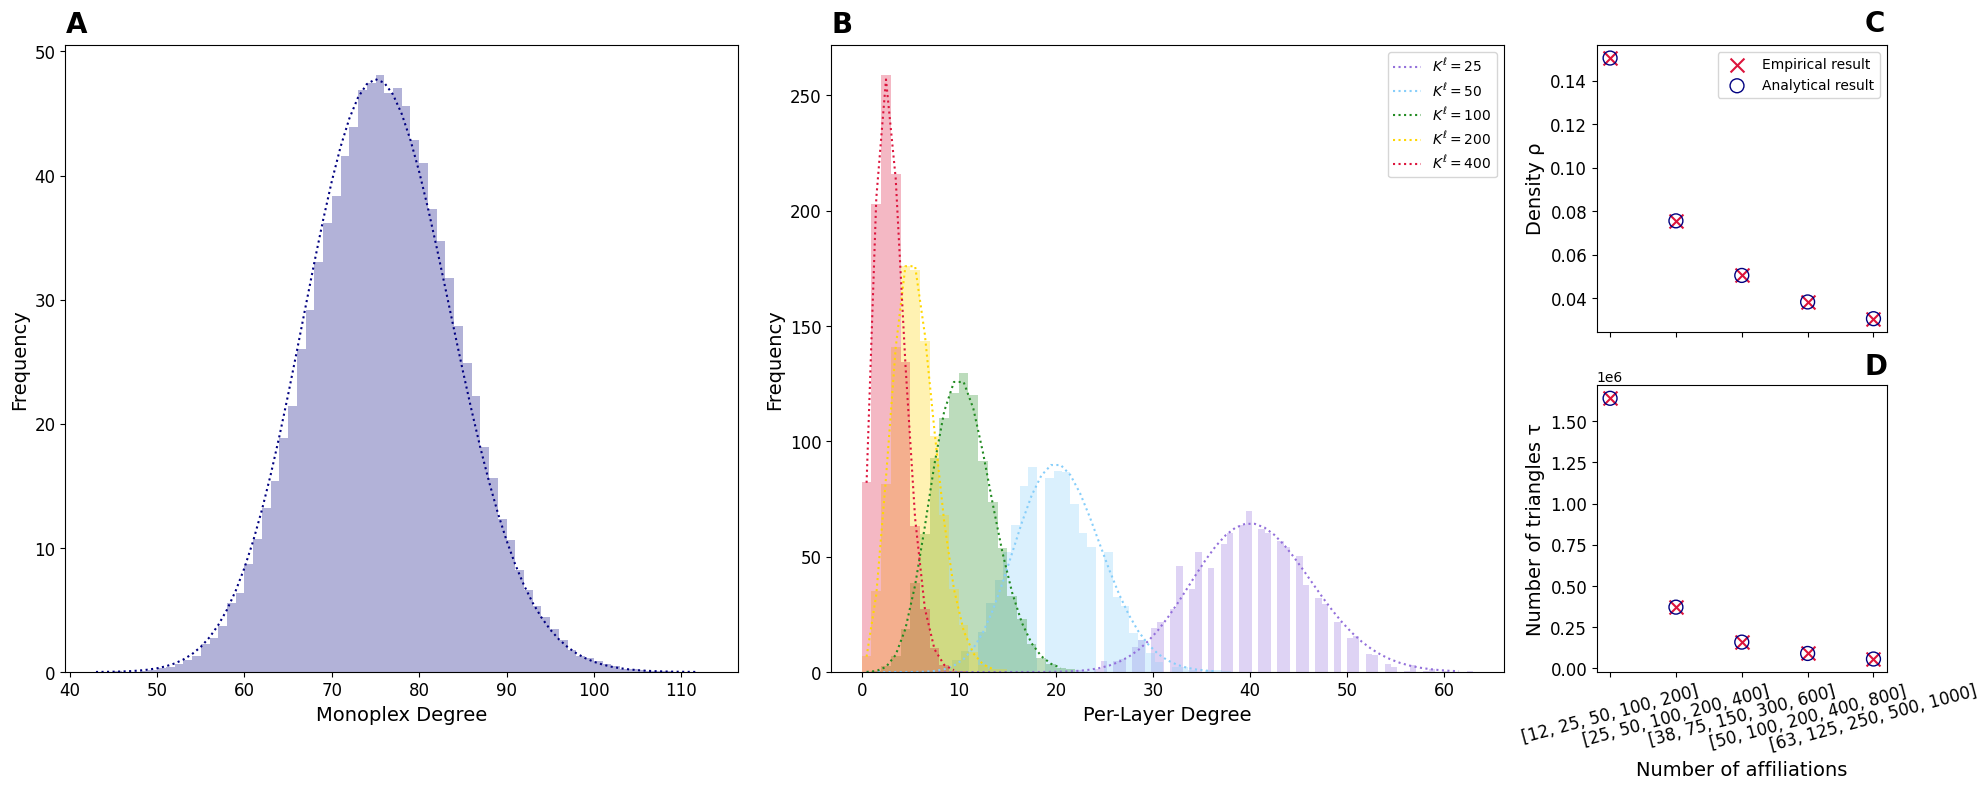

In [93]:
# Plotting results

# Initialise figure and subplots
fig = plt.figure(figsize=(20,8))

ax_mdd = plt.subplot2grid((4,5), (0,0), rowspan=5, colspan=2, fig=fig) # Axis for monoplex degree distribution
ax_ldd = plt.subplot2grid((4,5), (0,2), rowspan=5, colspan=2, fig=fig) # Axis for per layer degree distribution

ax_rho = plt.subplot2grid((4,5), (0,4), fig=fig, rowspan=2) # Axis for densities
ax_tri = plt.subplot2grid((4,5), (2,4), fig=fig, rowspan=2, sharex=ax_rho) # Axis for triangle counts
plt.setp(ax_rho.get_xticklabels(), visible=False)

# Plot the histogram for the monoplex degree distribution 
freqs, bins, _ = ax_mdd.hist(si_degrees, bins = 70)
ax_mdd.clear()

mps = [(bins[i] + bins[i+1])/ 2 for i in range(len(bins) - 1)]
mps = [mp for mp, f in zip(mps, freqs) if f != 0]
freqs = [f / n_trials for f in freqs if f != 0] # Scale down the frequencies to account for the number of trials

bin_width = bins[1] - bins[0]
ax_mdd.bar(mps, freqs, color='navy', alpha=0.3, width=bin_width) # Plot the scaled down histogram

# Plot the expected monoplex degree distribution
N = cfg.network.n_nodes
rho = 1 - math.prod([1 - 1/K for K in cfg.network.n_affiliations]) # Calculate the expected density ρ

xs = [i for i in range(int(min(bins)), int(max(bins)))]
ys = [N * math.comb(N-1, int(k)) * (rho**k) * ((1-rho)**(N-1-k)) for k in xs] # The expected degree distribution is a binomial distribution with p = ρ
ax_mdd.plot(xs, ys, color='navy', ls=':')

# Plot the histogram for the per-layer degree distributions
all_layer_freqs = [] # Store the frequencies for each layer
all_layer_mps = [] # Store the midpoints for each layer
bin_widths = [] # Store the bin widths for each layer

for l_degrees in si_layer_degrees:
    l_freqs, l_bins, _ = ax_ldd.hist(l_degrees, bins = 120)
    l_freqs, l_bins, _ = ax_ldd.hist(l_degrees, bins = int(max(l_bins)))
    ax_ldd.clear()

    l_mps = [(l_bins[i] + l_bins[i+1])/ 2 for i in range(len(l_bins) - 1)]
    l_mps = [mp for mp, f in zip(l_mps, l_freqs) if f != 0]
    l_freqs = [f / n_trials for f in l_freqs if f != 0] # Scale down the frequencies to account for the number of trials

    all_layer_freqs.append(l_freqs)
    all_layer_mps.append(l_mps)
    bin_widths.append(l_bins[1] - l_bins[0])

layer_colours = ['mediumpurple', 'lightskyblue', 'forestgreen', 'gold', 'crimson'] # Determine colours to plot the different histograms

for mp, freq, c, bin_width in zip(all_layer_mps, all_layer_freqs, layer_colours, bin_widths): # Plot each histogram
    ax_ldd.bar(mp, freq, color=c, alpha=0.3, width=bin_width)

# Plot the expected per-layer degree distributions
for mps, K, c in zip(all_layer_mps, cfg.network.n_affiliations, layer_colours):
    xs = [i for i in range(0, int(max(mps)))]
    ys = [N * math.comb(N-1, int(k)) * ((1/K)**k) * ((1-(1/K))**(N-1-k)) for k in xs] # The expected degree distribution is a binomial distribution with p = 1/K
    xs = [i + 0.5 for i in xs]
    ax_ldd.plot(xs, ys, ls=':', color=c, label=f'$K^\ell = ${K}')

# Plot the density and number of triangles
labels = [str(Ks) for Ks in affiliation_combs] # The categorical scatter chart is labelled with the affiliation size distributions.

ax_rho.scatter(labels, si_rhos, color='crimson', marker='x', s=100, label='Empirical result')
ax_tri.scatter(labels, si_tris, color='crimson', marker = 'x', s=100)

# Plot the expected density and number of triangles
ax_rho.scatter(labels, [1 - math.prod([1 - 1/K for K in Ks]) for Ks in affiliation_combs], color='navy', marker='o', facecolor="None", s=100, label='Analytical result')
ax_tri.scatter(labels, [math.comb(N, 3) * (1 - 3 * math.prod([1 - (1/K) for K in Ks]) + 3 * math.prod([1 - (2/K) + (1/K)**2 for K in Ks]) - math.prod([1 - (3/K) + 2 * (1/K)**2 for K in Ks])) for Ks in affiliation_combs], color='navy', marker = 'o', facecolor="None", s= 100)

# Label axes
axes_label_fs = 14
tick_label_fs = 12
ax_mdd.tick_params(labelsize=tick_label_fs)
ax_mdd.set_xlabel("Monoplex Degree", fontsize=axes_label_fs)
ax_mdd.set_ylabel("Frequency", fontsize=axes_label_fs)

ax_ldd.tick_params(labelsize=tick_label_fs)
ax_ldd.set_xlabel("Per-Layer Degree", fontsize=axes_label_fs)
ax_ldd.set_ylabel("Frequency", fontsize=axes_label_fs)

ax_tri.set_xticks(labels, labels, rotation=15)
ax_tri.tick_params(labelsize=tick_label_fs)
ax_rho.tick_params(labelsize=tick_label_fs)

ax_rho.set_ylabel("Density ρ", fontsize=axes_label_fs)
ax_tri.set_ylabel("Number of triangles τ", fontsize=axes_label_fs)
ax_tri.set_xlabel("Number of affiliations", fontsize=axes_label_fs)

# Add legend
ax_ldd.legend(loc='upper right')

# Label each plot
x_min, _ = ax_mdd.get_xlim()
_, y_max = ax_mdd.get_ylim()
ax_mdd.text(x_min, y_max*1.02, 'A', fontweight='bold', fontsize=20)

x_min, _ = ax_ldd.get_xlim()
_, y_max = ax_ldd.get_ylim()
ax_ldd.text(x_min, y_max*1.02, 'B', fontweight='bold', fontsize=20)

_, x_max = ax_rho.get_xlim()
_, y_max = ax_rho.get_ylim()
ax_rho.text(x_max*0.92, y_max*1.04, 'C', fontweight='bold', fontsize=20)
ax_rho.legend(loc='upper right')

_, x_max = ax_tri.get_xlim()
_, y_max = ax_tri.get_ylim()
ax_tri.text(x_max*0.92, y_max*1.04, 'D', fontweight='bold', fontsize=20)

# Display graphic
fig.tight_layout()
fig.show()

## Hard Geometric Case

In [94]:
# Comparison of empirical and analytical results

n_trials = 100 # Generate 100 networks and take the mean

# Set alpha to 100 to obtain the space-independent case
original_alpha = cfg.connection.alpha
cfg.connection.alpha = 0.001

# Initialise lists to store the plotted results
degrees = [] # Monoplex degree distribution
layer_degrees = [[] for _ in range(cfg.network.n_layers)] # Degree distribution for each layer
rhos = [] # Density
tris = [] # Number of triangles

# Generate n_trials networks and store the monoplex and by-layer degree distributions of each. 
# These networks are on 1000 nodes with 25, 50, 100, 200 and 400 affiliations.
for _ in range(n_trials):
    G, layers = gen(cfg, rng)
    degrees.extend([d for v, d in G.degree])
    for i, Gl in enumerate(layers):
        layer_degrees[i].extend([d for v, d in Gl.degree])

# Iterate through different affiliation size distributions and generate 100 networks for each. 
# Find the mean density and number of triangles for each.
affiliation_combs = [[12, 25, 50, 100, 200], [25, 50, 100, 200, 400], [38, 75, 150, 300, 600], [50, 100, 200, 400, 800], [63, 125, 250, 500, 1000]]
original_Ks = cfg.network.n_affiliations

for Ks in affiliation_combs:
    cfg.network.n_affiliations = Ks
    rho = 0
    tri = 0 
    for _ in range(n_trials):
        G, _ = gen(cfg, rng)
        rho += nx.density(G)
        tri += sum([t for t in nx.triangles(G).values()])/3
    rhos.append(rho / n_trials)
    tris.append(tri / n_trials)

cfg.connection.alpha = original_alpha # Reset alpha
cfg.network.n_affiliations = original_Ks # Reset the number of affiliations

In [183]:
#affiliation_combs =  [[12, 25, 50, 100, 200], [25, 50, 100, 200, 400], [38, 75, 150, 300, 600], [50, 100, 200, 400, 800], [63, 125, 250, 500, 1000]]

affiliation_combs = [[63, 125, 250, 500, 1000]]

analytical_rhos = []

n = 1_000 # cfg.analysis.mc_n_trials

for Ks in affiliation_combs:
    print(f"\r{Ks}")
    total = 0
    for i in range(n):
        print(f"\r{i}", end="")
        u_pos = (random.uniform(0,1), random.uniform(0,1))
        v_pos = (random.uniform(0,1), random.uniform(0,1))

        prob = 1
        for K in Ks:
            prob *= 1 - mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K)
        total += 1 - prob

    analytical_rhos.append(total / n)

[63, 125, 250, 500, 1000]
999

In [182]:
analytical_rhos

[0.02590780759462588]

In [179]:
analytical_rhos = [0.152159682752996,
 0.07929251779145335,
 0.048971150056179,
 0.03360478604157373,
 0.023314580977490076]
analytical_rhos

[0.152159682752996,
 0.07929251779145335,
 0.048971150056179,
 0.03360478604157373,
 0.023314580977490076]

In [28]:
# Save results for later

hg_degrees = degrees.copy() 
hg_layer_degrees = layer_degrees.copy() 
hg_rhos = rhos.copy()
hg_tris = tris.copy()

with open('hg_plot_properties.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile, delimiter=',')
    writer.writerow(hg_degrees)
    for l in hg_layer_degrees:
        writer.writerow(l)
    writer.writerow(hg_rhos)
    writer.writerow(hg_tris)

NameError: name 'degrees' is not defined

In [34]:
# Run this cell to read results from file

with open('hg_plot_properties.csv', 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    lines = [line for i, line in enumerate(reader)]
    hg_degrees = [int(k) for k in lines[0]]
    hg_layer_degrees = [[int(k) for k in lines[i+1]] for i in range(cfg.network.n_layers)]
    hg_rhos = [float(rho) for rho in lines[cfg.network.n_layers+1]]
    hg_tris = [float(tri) for tri in lines[cfg.network.n_layers+2]]

In [173]:
affiliation_combs = [[12, 25, 50, 100, 200], [25, 50, 100, 200, 400], [38, 75, 150, 300, 600], [50, 100, 200, 400, 800], [63, 125, 250, 500, 1000]]


In [174]:
hg_rhos

[0.1364279279279279,
 0.06802820820820824,
 0.04498906906906907,
 0.034519759759759766,
 0.027139199199199195]

In [163]:
def gamma_pdf(xs, alpha, beta):
    return [(beta**alpha / math.gamma(alpha)) * x**(alpha - 1) * math.e**(-beta*x) for x in xs]

In [169]:
def fit_gamma_params(xs, true_ys, alpha_range, beta_range, N):
    fitted_alpha = 0
    fitted_beta = 0
    best_score = 10**10
    for alpha in alpha_range:
        for beta in beta_range:
            fitted_ys = gamma_pdf(xs, alpha, beta)
            score = np.mean([math.sqrt((N*fitted_y - true_y)**2) for fitted_y, true_y in zip(fitted_ys, true_ys)])
            if score < best_score:
                best_score = score
                fitted_alpha = alpha
                fitted_beta = beta
    return fitted_alpha, fitted_beta

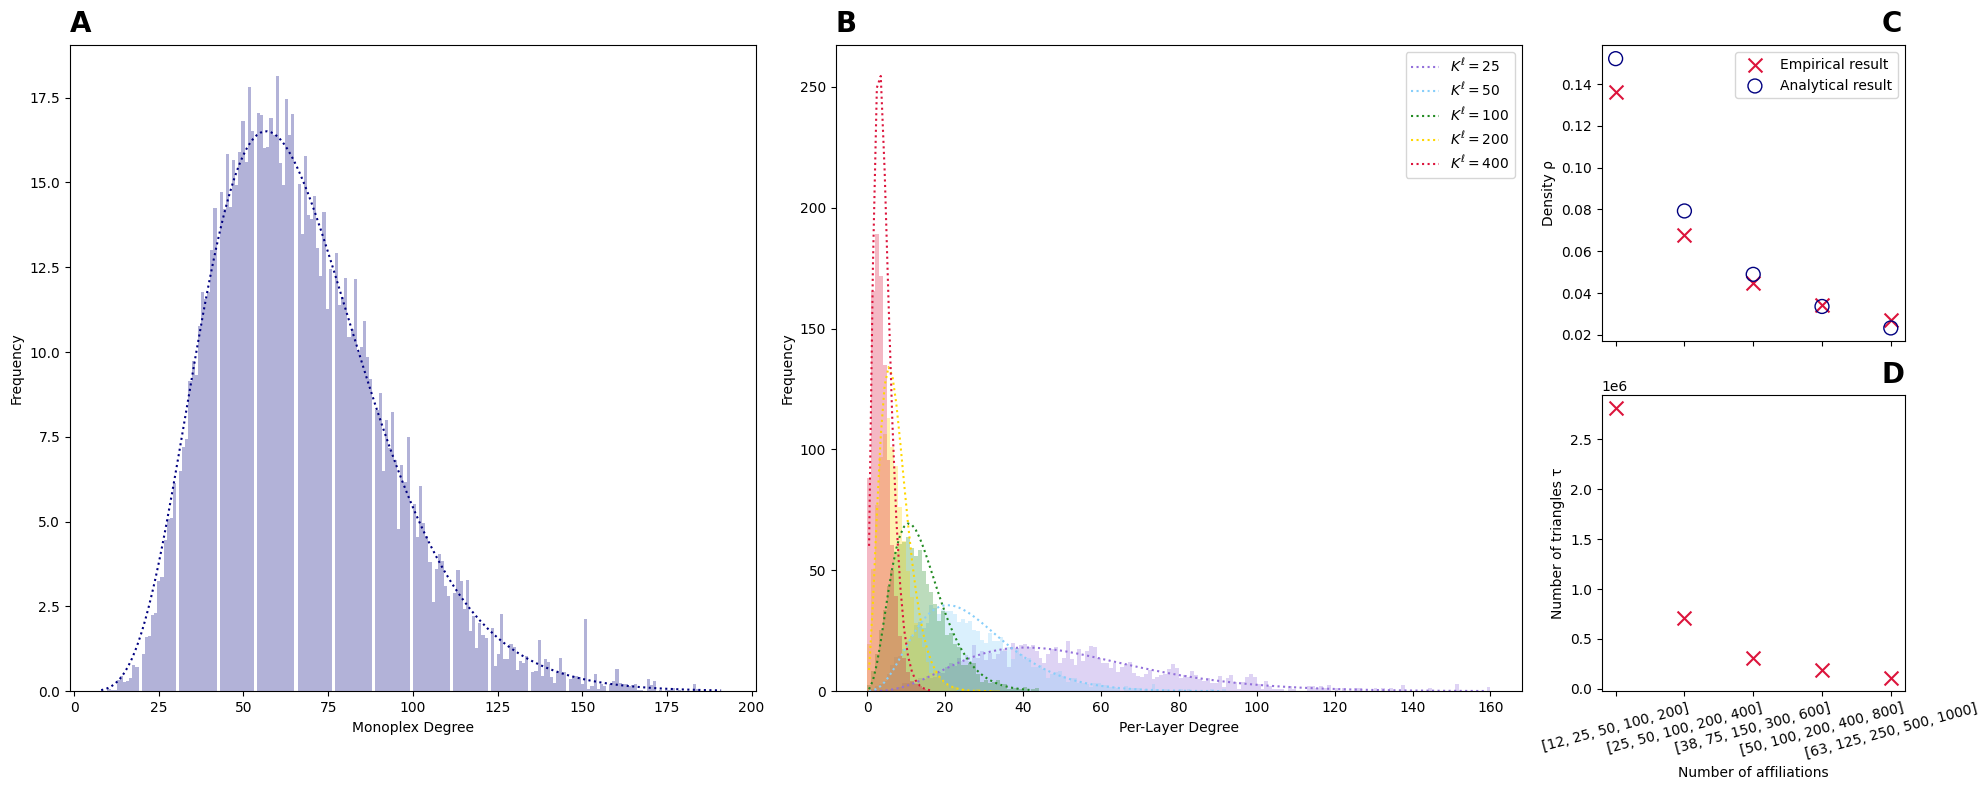

In [180]:
# Plotting

n_trials = 100

# Initialise figure and subplots
fig = plt.figure(figsize=(20,8))

ax_mdd = plt.subplot2grid((4,5), (0,0), rowspan=5, colspan=2, fig=fig) # Axis for monoplex degree distribution
ax_ldd = plt.subplot2grid((4,5), (0,2), rowspan=5, colspan=2, fig=fig) # Axis for per layer degree distribution

ax_rho = plt.subplot2grid((4,5), (0,4), fig=fig, rowspan=2) # Axis for densities
ax_tri = plt.subplot2grid((4,5), (2,4), fig=fig, rowspan=2, sharex=ax_rho) # Axis for triangle counts
plt.setp(ax_rho.get_xticklabels(), visible=False)

# Plot the histogram for the monoplex degree distribution 
freqs, bins, _ = ax_mdd.hist(hg_degrees, bins = 200)
ax_mdd.clear()

mps = [(bins[i] + bins[i+1])/ 2 for i in range(len(bins) - 1)]
mps = [mp for mp, f in zip(mps, freqs) if f != 0]
freqs = [f / n_trials for f in freqs if f != 0] # Scale down the frequencies to account for the number of trials

bin_width = bins[1] - bins[0]
ax_mdd.bar(mps, freqs, color='navy', alpha=0.3, width=bin_width) # Plot the scaled down histogram

# Plot the expected monoplex degree distribution
N = cfg.network.n_nodes
alpha, beta = fit_gamma_params(mps, freqs, np.linspace(1, 10, 101), np.linspace(0, 10, 101), N)

xs = [i for i in range(int(min(bins)), int(max(bins)))]
ys = [N * y for y in gamma_pdf(xs, alpha, beta)]

ax_mdd.plot(xs, ys, color='navy', ls=':')

# Plot the histogram for the per-layer degree distributions
all_layer_freqs = [] # Store the frequencies for each layer
all_layer_mps = [] # Store the midpoints for each layer
bin_widths = [] # Store the bin widths for each layer

for l_degrees in hg_layer_degrees:
    l_freqs, l_bins, _ = ax_ldd.hist(l_degrees, bins = 120)
    l_freqs, l_bins, _ = ax_ldd.hist(l_degrees, bins = int(max(l_bins)))
    ax_ldd.clear()

    l_mps = [(l_bins[i] + l_bins[i+1])/ 2 for i in range(len(l_bins) - 1)]
    l_mps = [mp for mp, f in zip(l_mps, l_freqs) if f != 0]
    l_freqs = [f / n_trials for f in l_freqs if f != 0] # Scale down the frequencies to account for the number of trials

    all_layer_freqs.append(l_freqs)
    all_layer_mps.append(l_mps)
    bin_widths.append(l_bins[1] - l_bins[0])

layer_colours = ['mediumpurple', 'lightskyblue', 'forestgreen', 'gold', 'crimson'] # Determine colours to plot the different histograms

for mp, freq, c, bin_width in zip(all_layer_mps, all_layer_freqs, layer_colours, bin_widths): # Plot each histogram
    ax_ldd.bar(mp, freq, color=c, alpha=0.3, width=bin_width)

# Plot the expected per-layer degree distributions
for mps, K, c in zip(all_layer_mps, cfg.network.n_affiliations, layer_colours):
    xs = [i for i in range(0, int(max(mps)))]
    #ys = [N * math.comb(N-1, int(k)) * ((1/K)**k) * ((1-(1/K))**(N-1-k)) for k in xs] # The expected degree distribution is a binomial distribution with p = 1/K
    a = 3.57
    try:
        ys = [(k+1)*K*(math.gamma(k + a) / (math.gamma(k + 1) * math.gamma(a))) * ((N/K)**k * a**a)/((N/K + a)**(k+a)) for k in xs]
        #ys = [((k+1) / N) * K * (math.gamma(k + 1 + a) / (math.gamma(k + 2) * math.gamma(a))) * ((N**(k+1) * (K*a)**a)/ ((K*a + N)**(k+1+a))) for k in xs]
        xs = [i + 0.5 for i in xs]
        ax_ldd.plot(xs, ys, ls=':', color=c, label=f'$K^\ell = ${K}')
    except:
        print(f"couldn't plot for K={K}")

# Plot the density and number of triangles
labels = [str(Ks) for Ks in affiliation_combs] # The categorical scatter chart is labelled with the affiliation size distributions.

ax_rho.scatter(labels, hg_rhos, color='crimson', marker='x', s=100, label='Empirical result')
ax_tri.scatter(labels, hg_tris, color='crimson', marker = 'x', s=100)

# Plot the expected density and number of triangles
ax_rho.scatter(labels[:len(analytical_rhos)], analytical_rhos, color='navy', marker='o', facecolor="None", s=100, label='Analytical result')
#ax_tri.scatter(labels, [math.comb(N, 3) * (1 - 3 * math.prod([1 - (1/K) for K in Ks]) + 3 * math.prod([1 - (2/K) + (1/K)**2 for K in Ks]) - math.prod([1 - (3/K) + 2 * (1/K)**2 for K in Ks])) for Ks in affiliation_combs], color='navy', marker = 'o', facecolor="None", s= 100)

# Label axes
ax_mdd.set_xlabel("Monoplex Degree")
ax_mdd.set_ylabel("Frequency")

ax_ldd.set_xlabel("Per-Layer Degree")
ax_ldd.set_ylabel("Frequency")

ax_tri.set_xticks(labels, labels, rotation=15)

ax_rho.set_ylabel("Density ρ")
ax_tri.set_ylabel("Number of triangles τ")
ax_tri.set_xlabel("Number of affiliations")

# Add legend
ax_ldd.legend(loc='upper right')

# Label each plot
x_min, _ = ax_mdd.get_xlim()
_, y_max = ax_mdd.get_ylim()
ax_mdd.text(x_min, y_max*1.02, 'A', fontweight='bold', fontsize=20)

x_min, _ = ax_ldd.get_xlim()
_, y_max = ax_ldd.get_ylim()
ax_ldd.text(x_min, y_max*1.02, 'B', fontweight='bold', fontsize=20)

_, x_max = ax_rho.get_xlim()
_, y_max = ax_rho.get_ylim()
ax_rho.text(x_max*0.92, y_max*1.04, 'C', fontweight='bold', fontsize=20)
ax_rho.legend(loc='upper right')

_, x_max = ax_tri.get_xlim()
_, y_max = ax_tri.get_ylim()
ax_tri.text(x_max*0.92, y_max*1.04, 'D', fontweight='bold', fontsize=20)

# Display graphic
fig.tight_layout()
fig.show()

6.67 0.1


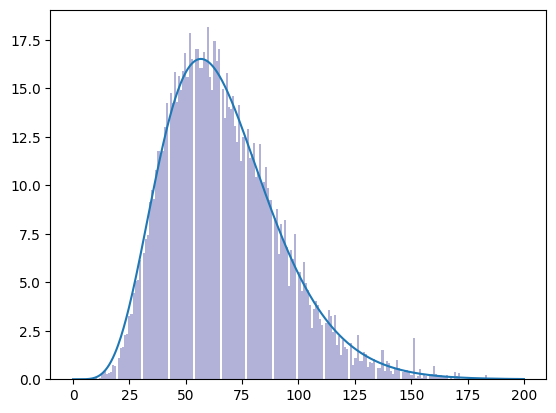

In [170]:
# Plot the histogram for the monoplex degree distribution 
freqs, bins, _ = plt.hist(hg_degrees, bins = 200)
plt.clf()

mps = [(bins[i] + bins[i+1])/ 2 for i in range(len(bins) - 1)]
mps = [mp for mp, f in zip(mps, freqs) if f != 0]
freqs = [f / n_trials for f in freqs if f != 0] # Scale down the frequencies to account for the number of trials

bin_width = bins[1] - bins[0]
plt.bar(mps, freqs, color='navy', alpha=0.3, width=bin_width) # Plot the scaled down histogram

alpha, beta = fit_gamma_params(mps, freqs, np.linspace(1, 10, 101), np.linspace(0, 10, 101), 1000)
print(alpha, beta)

xs = np.linspace(0, 200, 500)
plt.plot(xs, [1000*y for y in gamma_pdf(xs, alpha, beta)])

# Other things I could add

* Layer overlap